# 🔬 Bitcoin Price Prediction — Research Notebook
## NexTide Analytics | ML Research & Model Development

**Tujuan:** Membangun model prediksi harga Bitcoin terbaik melalui pendekatan ilmiah yang rigorous.  
**Output:** Model `.pkl` / `.keras` siap digunakan oleh backend pipeline.

### Filosofi Riset
> *"Sejarah selalu berulang — psikologi manusia menciptakan pola yang dapat dipelajari."*

Candlestick chart adalah visualisasi perilaku kolektif manusia: ketakutan, keserakahan, FOMO, dan panik.  
Model kita bertugas mengenali pola psikologis berulang ini dari data historis.

---
### Struktur Notebook
| # | Section | Tujuan |
|---|---------|--------|
| 1 | **Data Ingestion** | Fetch OHLCV dari Binance + Fear & Greed Index |
| 2 | **Exploratory Data Analysis (EDA)** | Pahami distribusi, korelasi, halving cycles |
| 3 | **Feature Engineering** | 25+ indikator teknis + halving flags + sentimen |
| 4 | **Preprocessing & PCA** | Scaling, PCA tuning, sequence building |
| 5 | **Multi-Horizon Targets** | y₁, y₇, y₃₀ (harian, mingguan, bulanan) |
| 6A | **XGBoost** | Baseline + Optuna hyperparameter tuning |
| 6B | **LSTM** | Optimized deep learning architecture |
| 6C | **TFT** | Temporal Fusion Transformer |
| 7 | **Model Comparison** | Head-to-head RMSE + Directional Accuracy |
| 8 | **Feature Importance** | Apa yang paling prediktif? |
| 9 | **Export** | Simpan model + artefak preprocessing |


## ⚙️ 0. Setup & Dependencies

In [ ]:
# Install semua dependency yang dibutuhkan
# Jalankan cell ini sekali, lalu restart kernel jika diminta

# !pip install pandas pandas_ta numpy scikit-learn xgboost tensorflow
# !pip install torch torchvision torchaudio pytorch-lightning pytorch-forecasting
# !pip install joblib yfinance ccxt requests optuna matplotlib seaborn



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 12.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 11.0 MB/s  0:00:00
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)

   ----------------------------------------  0/11 [peewee]
   ----------------------------------------  0/11 [peewee]
   ----------------------------------------  0/11 [peewee]
   ----------------------------------------  0/11 [peewee]
   ----------------------------------------  0/11 [peewee]
   ------- --------------------------------  2/11 [websockets]
   ------- --------------------------------  2/11 [websockets]
   ------- --------------------------------  2/11 [websockets]
   ------- --------------------------------  2/11 [websockets]
   ------- --------------------------------  2/


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TF logs

# Core
import pandas as pd
import numpy as np
import joblib
import json
from datetime import datetime, timedelta
from pathlib import Path

# Data & API
import ccxt
import requests

# Technical Analysis
import pandas_ta as ta

# Preprocessing & ML
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# Models
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input, Bidirectional,
    BatchNormalization, Conv1D, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = Path('./models_output')
OUTPUT_DIR.mkdir(exist_ok=True)

print('✅ Semua library berhasil diimport')
print(f'📁 Output directory: {OUTPUT_DIR.resolve()}')
print(f'TensorFlow version: {tf.__version__}')
print(f'XGBoost version: {xgb.__version__}')


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✅ Semua library berhasil diimport
📁 Output directory: D:\Code\PROJECT-ML_Pribadi\Bitcoin-MLOps-dashboard\Research-Modelling\models_output
TensorFlow version: 2.18.0
XGBoost version: 3.2.0


## 📥 1. Data Ingestion

### Strategi Data
- **OHLCV:** Binance via `ccxt` — dari 2017 hingga hari ini (~2800+ hari)
- **Fear & Greed Index:** `alternative.me` API — tersedia sejak Feb 2018
- **Halving Events:** Hardcoded (tanggal pasti, bukan estimasi)

### Mengapa 2017?
Mencakup **2 siklus halving penuh** (2020 & 2024), termasuk:
- Bull market 2017 (ATH ~$20K)
- Crypto winter 2018–2019
- Halving rally 2020–2021 (ATH ~$69K)
- Bear market 2022 (FTX collapse)
- Bull market 2024–2025 (ATH >$100K)


In [3]:
# ── Konfigurasi Global ────────────────────────────────────────────────────────
SYMBOL        = 'BTC/USDT'
TIMEFRAME     = '1d'
START_DATE    = '2017-01-01'  # Mencakup 2 halving event
SEQUENCE_LEN  = 30            # Melihat 30 hari ke belakang
TRAIN_RATIO   = 0.8
N_PCA_COMPONENTS = None       # None = auto-tune berdasarkan explained variance
RANDOM_SEED   = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ── Bitcoin Halving Dates (sumber: blockchain.com) ────────────────────────────
# Halving adalah event di mana reward mining Bitcoin dipotong 50%
# Secara historis selalu diikuti siklus bull market 12-18 bulan setelahnya
HALVING_DATES = [
    pd.Timestamp('2012-11-28'),  # Halving #1: 50 → 25 BTC/block
    pd.Timestamp('2016-07-09'),  # Halving #2: 25 → 12.5 BTC/block
    pd.Timestamp('2020-05-11'),  # Halving #3: 12.5 → 6.25 BTC/block
    pd.Timestamp('2024-04-20'),  # Halving #4: 6.25 → 3.125 BTC/block
]

print('🔧 Konfigurasi:')
print(f'  Symbol    : {SYMBOL}')
print(f'  Start     : {START_DATE}')
print(f'  Seq Length: {SEQUENCE_LEN} hari')
print(f'  Halving dates: {[str(d.date()) for d in HALVING_DATES]}')


🔧 Konfigurasi:
  Symbol    : BTC/USDT
  Start     : 2017-01-01
  Seq Length: 30 hari
  Halving dates: ['2012-11-28', '2016-07-09', '2020-05-11', '2024-04-20']


In [5]:
def fetch_btc_ohlcv(symbol=SYMBOL, timeframe=TIMEFRAME, start_date=START_DATE):
    """
    Fetch data OHLCV Bitcoin dari Binance menggunakan ccxt.
    
    Menggunakan pagination karena Binance membatasi 1000 candle per request.
    Data dimulai dari start_date hingga hari ini.
    """
    print(f'📡 Mengambil data {symbol} [{timeframe}] dari {start_date}...')
    
    exchange = ccxt.binance({'enableRateLimit': True})
    
    since_ms = exchange.parse8601(f'{start_date}T00:00:00Z')
    all_ohlcv = []
    
    while True:
        batch = exchange.fetch_ohlcv(symbol, timeframe=timeframe, since=since_ms, limit=1000)
        if not batch:
            break
        all_ohlcv.extend(batch)
        last_ts = batch[-1][0]
        if len(batch) < 1000:
            break
        since_ms = last_ts + 1
    
    df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms').dt.normalize()
    df.set_index('timestamp', inplace=True)
    df = df[~df.index.duplicated(keep='first')]
    df.sort_index(inplace=True)
    
    print(f'✅ {len(df):,} hari data | {df.index[0].date()} → {df.index[-1].date()}')
    return df


def fetch_fear_greed_index():
    """
    Fetch Fear & Greed Index historis dari alternative.me.
    
    Index 0-100:
      0-25   = Extreme Fear (potensi buying opportunity)
      25-45  = Fear
      45-55  = Neutral  
      55-75  = Greed
      75-100 = Extreme Greed (hati-hati, potensi koreksi)
    
    Tersedia sejak Februari 2018. Untuk periode sebelumnya (2017),
    kita akan menggunakan strategi forward-fill yang dijelaskan di EDA.
    
    Normalisasi: 0→-1.0, 50→0.0, 100→+1.0 agar konsisten dengan skala fitur lain.
    """
    print('📡 Mengambil Fear & Greed Index dari alternative.me...')
    
    url = 'https://api.alternative.me/fng/?limit=0'
    r = requests.get(url, timeout=15)
    r.raise_for_status()
    
    data = r.json()['data']
    fng = pd.DataFrame(data)
    fng['timestamp'] = pd.to_datetime(
        pd.to_numeric(fng['timestamp']), unit='s'
    ).dt.normalize()
    fng.set_index('timestamp', inplace=True)
    fng['fng_raw'] = pd.to_numeric(fng['value'])
    
    # Normalisasi ke [-1, 1]: (value / 50) - 1
    fng['fng_score'] = (fng['fng_raw'] / 50.0) - 1.0
    
    fng.sort_index(inplace=True)
    print(f'✅ {len(fng):,} hari F&G data | {fng.index[0].date()} → {fng.index[-1].date()}')
    return fng[['fng_raw', 'fng_score']]


# ── Jalankan Fetch ─────────────────────────────────────────────────────────────
raw_df  = fetch_btc_ohlcv()
fng_df  = fetch_fear_greed_index()

print(f'\n📊 Preview OHLCV:')
print(raw_df.head(3).to_string())
print(f'\n😱 Preview F&G:')
print(fng_df.head(3).to_string())


📡 Mengambil data BTC/USDT [1d] dari 2017-01-01...
✅ 3,191 hari data | 2017-08-17 → 2026-05-12
📡 Mengambil Fear & Greed Index dari alternative.me...
✅ 3,019 hari F&G data | 2018-02-01 → 2026-05-12

📊 Preview OHLCV:
               open     high      low    close       volume
timestamp                                                  
2017-08-17  4261.48  4485.39  4200.74  4285.08   795.150377
2017-08-18  4285.08  4371.52  3938.77  4108.37  1199.888264
2017-08-19  4108.37  4184.69  3850.00  4139.98   381.309763

😱 Preview F&G:
            fng_raw  fng_score
timestamp                     
2018-02-01       30       -0.4
2018-02-02       15       -0.7
2018-02-03       40       -0.2


## 🔍 2. Exploratory Data Analysis (EDA)

EDA bukan formalitas — ini adalah fondasi keputusan feature engineering kita.

**Yang akan kita pelajari:**
1. Distribusi harga & return — apakah normal atau fat-tailed?
2. Volatilitas across market cycles
3. Pola siklus halving — seberapa konsisten?
4. Korelasi Fear & Greed vs price movement
5. Seasonality — ada pola harian/bulanan/tahunan?


In [6]:
# ── 2.1 Overview Dataset ──────────────────────────────────────────────────────
print('=' * 60)
print('RINGKASAN DATASET OHLCV')
print('=' * 60)
print(f'Total baris   : {len(raw_df):,} hari')
print(f'Period        : {raw_df.index[0].date()} → {raw_df.index[-1].date()}')
print(f'Total hari    : {(raw_df.index[-1] - raw_df.index[0]).days:,}')
print(f'Missing dates : {pd.date_range(raw_df.index[0], raw_df.index[-1]).difference(raw_df.index).shape[0]}')
print()
print('Statistik Harga Close:')
print(raw_df['close'].describe().apply(lambda x: f'${x:,.2f}' if abs(x) > 1 else f'{x:.6f}'))


RINGKASAN DATASET OHLCV
Total baris   : 3,191 hari
Period        : 2017-08-17 → 2026-05-12
Total hari    : 3,190
Missing dates : 0

Statistik Harga Close:
count      $3,191.00
mean      $37,597.51
std       $32,483.87
min        $3,189.02
25%        $9,284.37
50%       $27,261.07
75%       $60,032.76
max      $124,658.54
Name: close, dtype: str


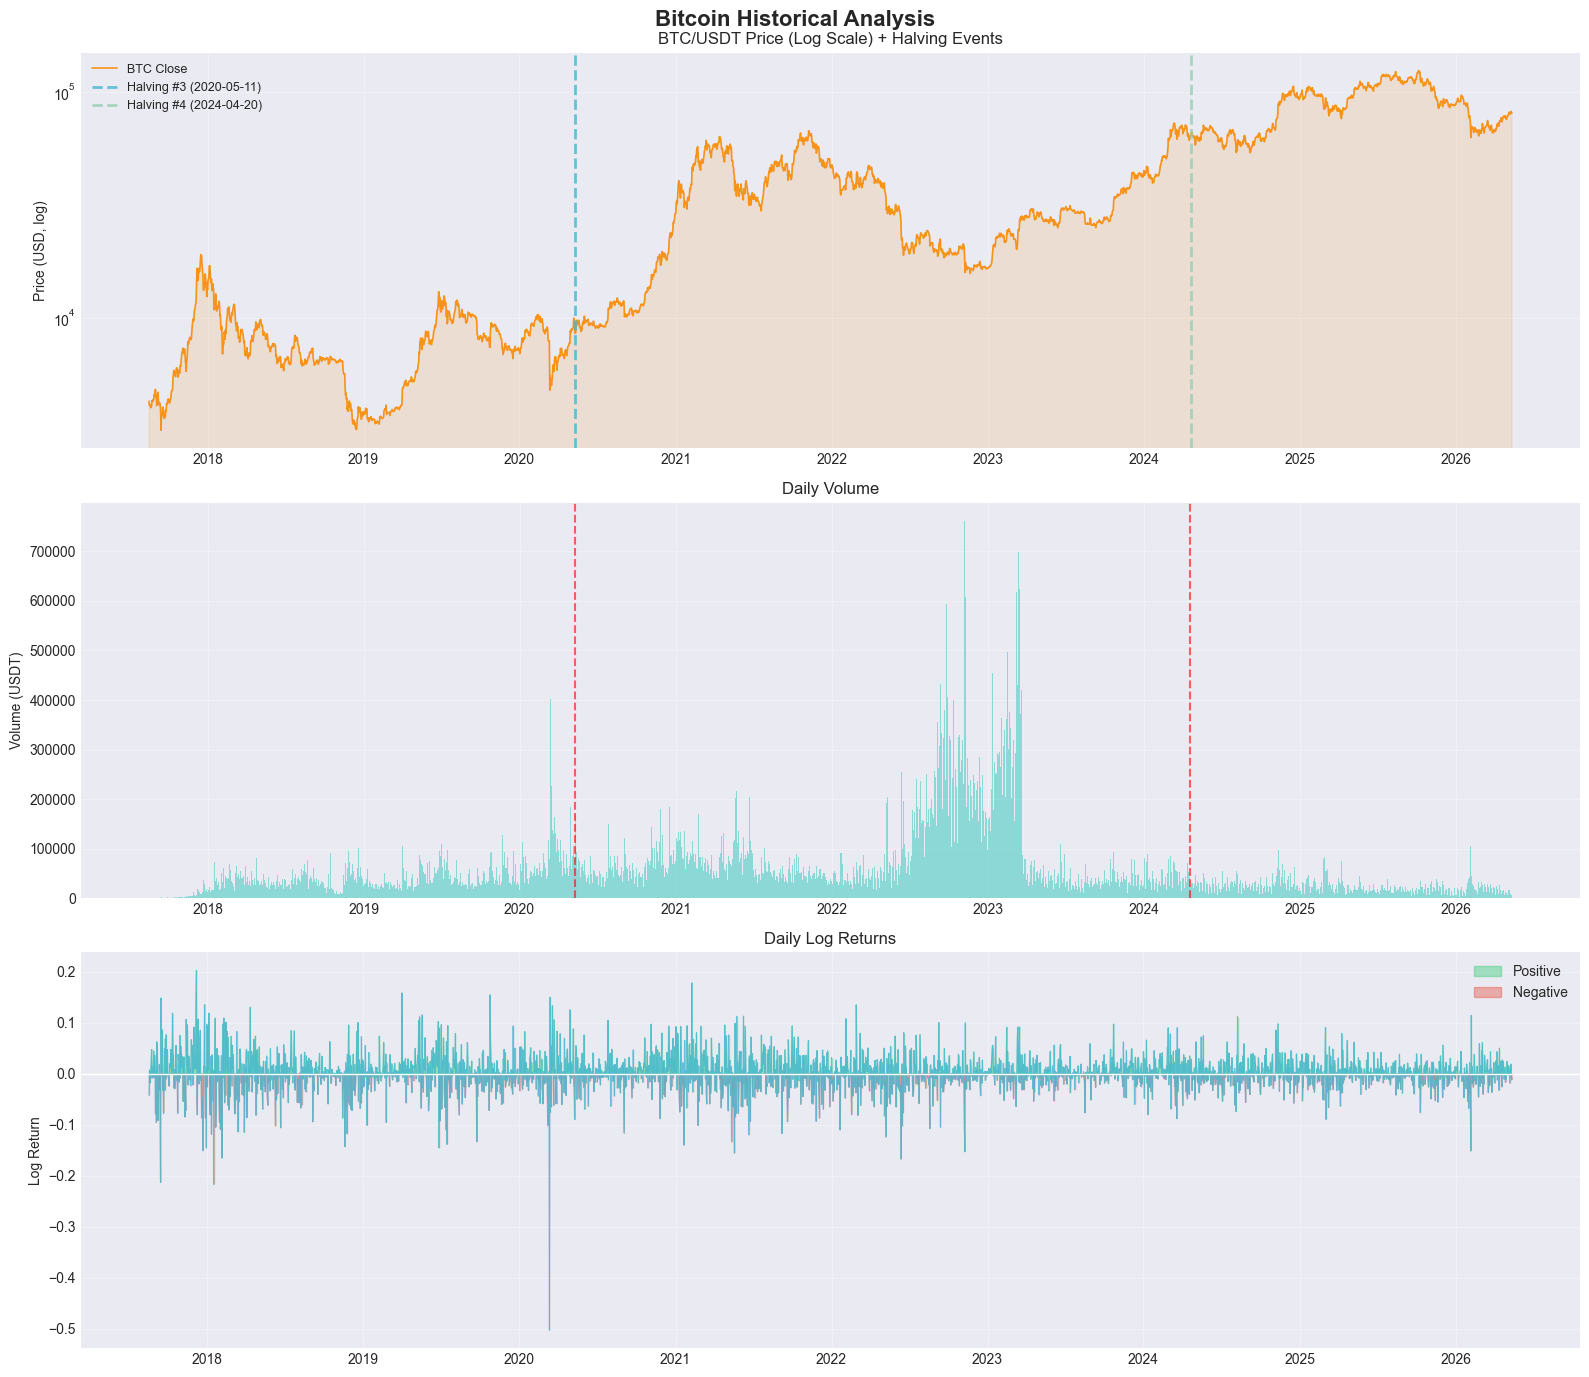

💾 Saved: eda_01_price_overview.png


In [7]:
# ── 2.2 Harga Bitcoin Sepanjang Waktu + Halving Annotations ──────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('Bitcoin Historical Analysis', fontsize=16, fontweight='bold', y=0.98)

# ── Plot 1: Harga (log scale) ─────────────────────────────────────────────────
ax1 = axes[0]
ax1.semilogy(raw_df.index, raw_df['close'], color='#F7931A', linewidth=1.2, label='BTC Close')
ax1.fill_between(raw_df.index, raw_df['close'], alpha=0.15, color='#F7931A')

# Tandai halving events
halving_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
for i, h_date in enumerate(HALVING_DATES):
    if h_date >= raw_df.index[0]:
        ax1.axvline(x=h_date, color=halving_colors[i % len(halving_colors)], 
                    linestyle='--', linewidth=2, alpha=0.8, 
                    label=f'Halving #{i+1} ({h_date.date()})')

ax1.set_title('BTC/USDT Price (Log Scale) + Halving Events', fontsize=12)
ax1.set_ylabel('Price (USD, log)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Volume ────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.bar(raw_df.index, raw_df['volume'], color='#4ECDC4', alpha=0.6, width=1)
for h_date in HALVING_DATES:
    if h_date >= raw_df.index[0]:
        ax2.axvline(x=h_date, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
ax2.set_title('Daily Volume', fontsize=12)
ax2.set_ylabel('Volume (USDT)')
ax2.grid(True, alpha=0.3)

# ── Plot 3: Log Returns ───────────────────────────────────────────────────────
log_ret = np.log(raw_df['close'] / raw_df['close'].shift(1)).dropna()
ax3 = axes[2]
ax3.plot(log_ret.index, log_ret, color='#45B7D1', linewidth=0.8, alpha=0.8)
ax3.axhline(y=0, color='white', linewidth=1)
ax3.fill_between(log_ret.index, log_ret, 0, 
                  where=log_ret > 0, alpha=0.4, color='#2ECC71', label='Positive')
ax3.fill_between(log_ret.index, log_ret, 0, 
                  where=log_ret < 0, alpha=0.4, color='#E74C3C', label='Negative')
ax3.set_title('Daily Log Returns', fontsize=12)
ax3.set_ylabel('Log Return')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_01_price_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_01_price_overview.png')


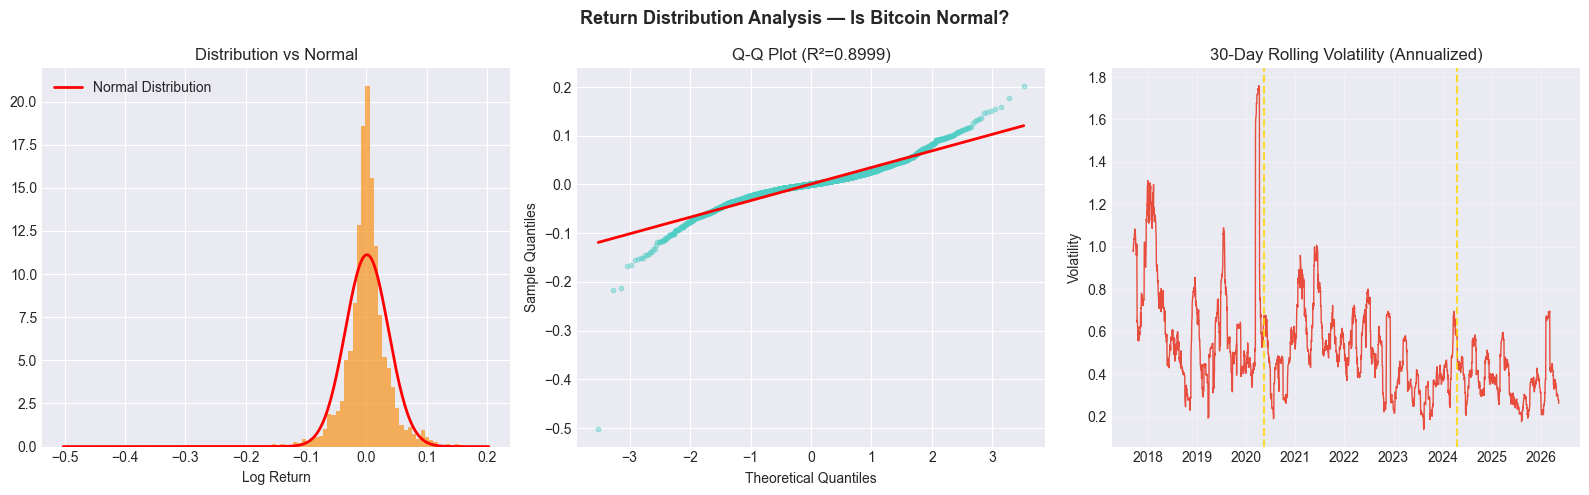


📊 Statistik Return:
  Kurtosis (excess)  : 15.6187  (Normal=0, BTC=15.62 → LEPTOKURTIC/fat-tailed)
  Skewness           : -0.9612  (Normal=0)
  p-value normaltest : 8.60e-233  (p<0.05 = TIDAK normal)

⚠️  Kesimpulan: Return Bitcoin memiliki fat tail — Directional Accuracy
    lebih relevan sebagai metrik dibanding RMSE murni untuk trading.


In [8]:
# ── 2.3 Distribusi Return — Fat Tail Analysis ────────────────────────────────
# Penting! Distribusi return Bitcoin BUKAN normal — fat tail berarti
# kejadian ekstrem lebih sering dari yang diprediksi distribusi normal.
# Ini mempengaruhi pilihan loss function model kita.

from scipy import stats

log_ret = np.log(raw_df['close'] / raw_df['close'].shift(1)).dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Return Distribution Analysis — Is Bitcoin Normal?', fontsize=13, fontweight='bold')

# Histogram + KDE vs Normal
ax = axes[0]
log_ret.hist(ax=ax, bins=100, density=True, alpha=0.7, color='#F7931A', edgecolor='none')
x = np.linspace(log_ret.min(), log_ret.max(), 300)
mu, sigma = log_ret.mean(), log_ret.std()
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal Distribution')
ax.set_title('Distribution vs Normal')
ax.set_xlabel('Log Return')
ax.legend()

# QQ Plot — jika data normal, titik akan mengikuti garis lurus
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(log_ret, dist='norm')
ax.scatter(osm, osr, alpha=0.4, s=10, color='#4ECDC4')
ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2)
ax.set_title(f'Q-Q Plot (R²={r**2:.4f})')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')

# Rolling Volatility — menangkap regime perubahan volatilitas
ax = axes[2]
rolling_vol = log_ret.rolling(30).std() * np.sqrt(252)  # Annualized
ax.plot(rolling_vol.index, rolling_vol, color='#E74C3C', lw=1)
for h_date in HALVING_DATES:
    if h_date >= raw_df.index[0]:
        ax.axvline(x=h_date, color='gold', linestyle='--', lw=1.5, alpha=0.8)
ax.set_title('30-Day Rolling Volatility (Annualized)')
ax.set_ylabel('Volatility')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_02_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistik distribusi
kurt = stats.kurtosis(log_ret)
skew = stats.skew(log_ret)
_, p_normal = stats.normaltest(log_ret)
print(f'\n📊 Statistik Return:')
print(f'  Kurtosis (excess)  : {kurt:.4f}  (Normal=0, BTC={kurt:.2f} → LEPTOKURTIC/fat-tailed)')
print(f'  Skewness           : {skew:.4f}  (Normal=0)')
print(f'  p-value normaltest : {p_normal:.2e}  (p<0.05 = TIDAK normal)')
print(f'\n⚠️  Kesimpulan: Return Bitcoin memiliki fat tail — Directional Accuracy')
print(f'    lebih relevan sebagai metrik dibanding RMSE murni untuk trading.')


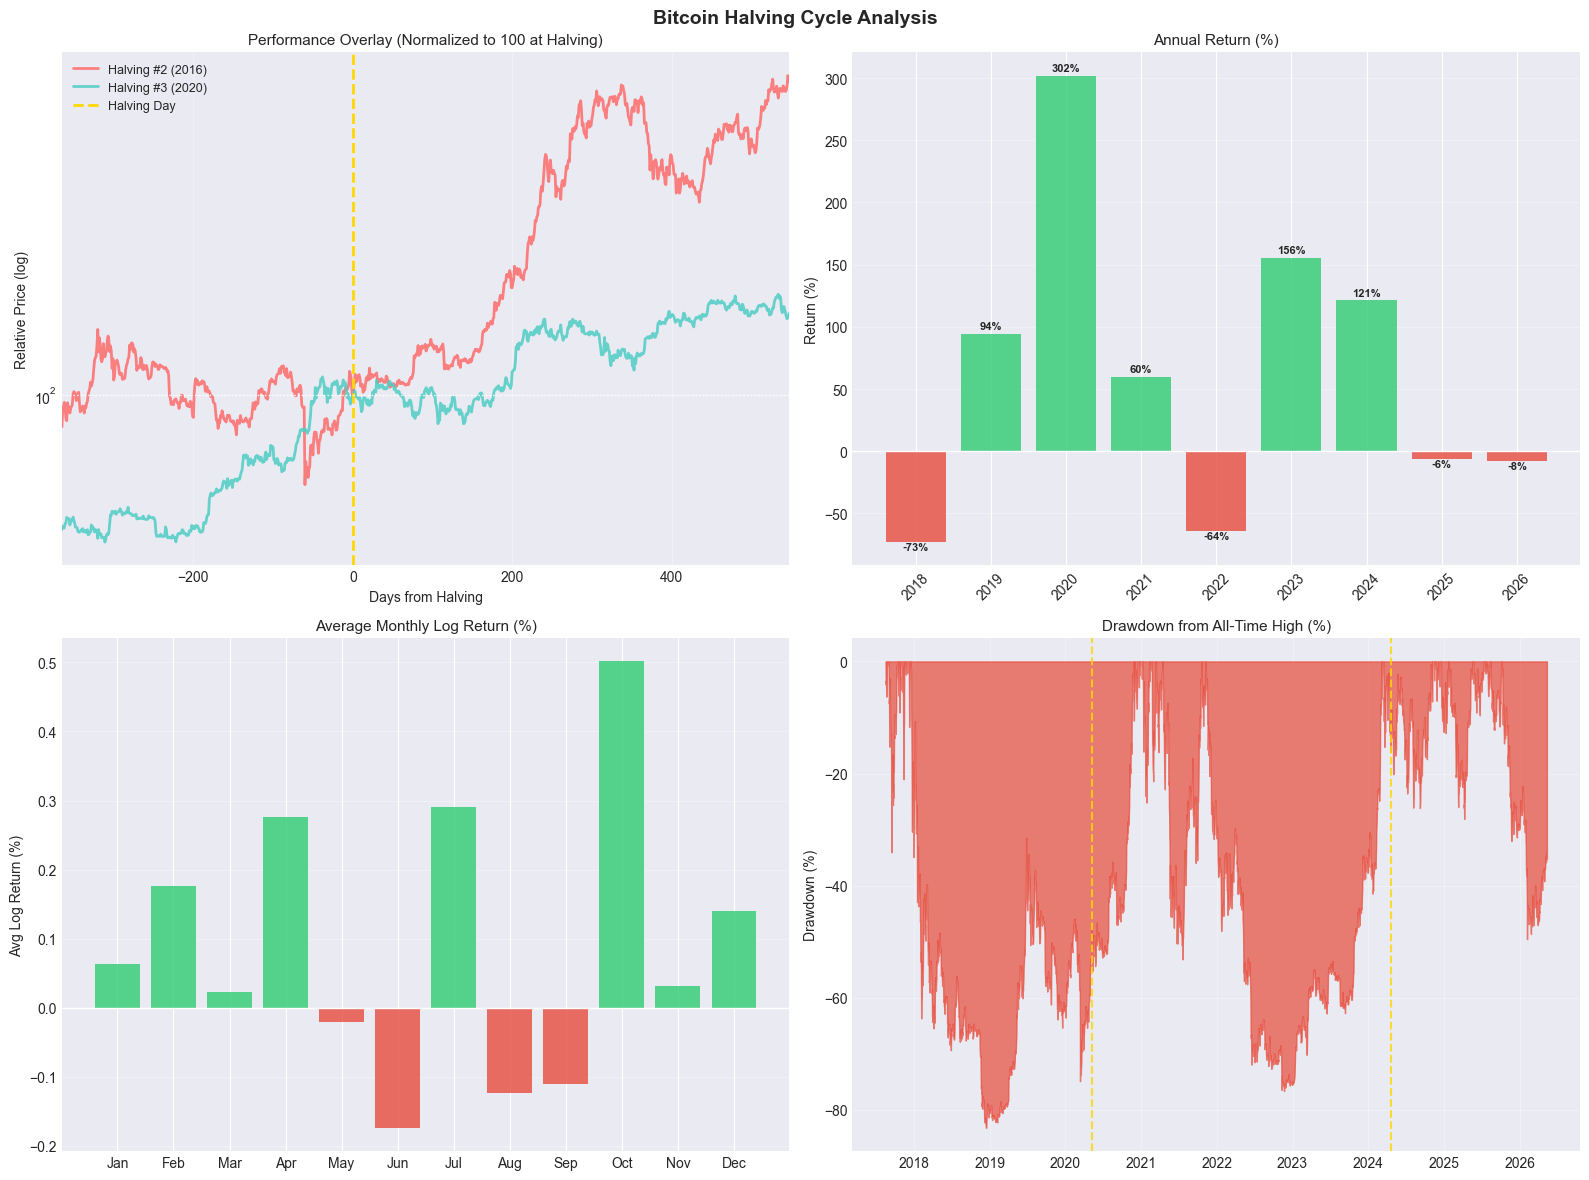


📊 Insight: Secara historis, BTC mengalami rally kuat 6-18 bulan SETELAH halving.
   Pola ini akan di-capture melalui fitur days_since_halving dan days_to_halving.


In [9]:
# ── 2.4 Analisis Siklus Halving ───────────────────────────────────────────────
# Berapa performa BTC di berbagai jarak dari halving?

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Bitcoin Halving Cycle Analysis', fontsize=14, fontweight='bold')

def get_performance_around_halving(df, halving_date, days_before=365, days_after=548):
    start = halving_date - pd.Timedelta(days=days_before)
    end   = halving_date + pd.Timedelta(days=days_after)
    mask  = (df.index >= start) & (df.index <= end)
    sub   = df.loc[mask, 'close'].copy()
    if len(sub) == 0:
        return None
    # Normalisasi ke 100 pada tanggal halving
    if halving_date in sub.index:
        base = sub[halving_date]
    else:
        base = sub.iloc[abs((sub.index - halving_date)).argmin()]
    return ((sub / base) * 100)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
halving_labels = ['Halving #2 (2016)', 'Halving #3 (2020)', 'Halving #4 (2024)']

# Plot overlay semua halving cycles
ax = axes[0, 0]
valid_halvings = [h for h in HALVING_DATES[1:] if h >= raw_df.index[0]]

for i, h_date in enumerate(valid_halvings):
    perf = get_performance_around_halving(raw_df, h_date)
    if perf is not None:
        # Buat x-axis sebagai "hari dari halving"
        days_from_halving = (perf.index - h_date).days
        ax.semilogy(days_from_halving, perf.values, 
                    color=colors[i], lw=2, label=halving_labels[i], alpha=0.85)

ax.axvline(x=0, color='gold', linestyle='--', lw=2, label='Halving Day')
ax.axhline(y=100, color='white', linestyle=':', lw=1)
ax.set_xlim(-365, 548)
ax.set_title('Performance Overlay (Normalized to 100 at Halving)', fontsize=11)
ax.set_xlabel('Days from Halving')
ax.set_ylabel('Relative Price (log)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Return per tahun kalender
ax = axes[0, 1]
yearly = raw_df['close'].resample('YE').last().pct_change().dropna() * 100
colors_bar = ['#2ECC71' if x > 0 else '#E74C3C' for x in yearly.values]
bars = ax.bar([str(y.year) for y in yearly.index], yearly.values, color=colors_bar, alpha=0.8)
ax.set_title('Annual Return (%)', fontsize=11)
ax.set_ylabel('Return (%)')
ax.axhline(y=0, color='white', lw=1)
for bar, val in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (2 if val > 0 else -8),
            f'{val:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Monthly seasonality (rata-rata return per bulan)
ax = axes[1, 0]
log_ret_df = pd.DataFrame({'log_ret': np.log(raw_df['close'] / raw_df['close'].shift(1))})
log_ret_df.dropna(inplace=True)
log_ret_df['month'] = log_ret_df.index.month
monthly_avg = log_ret_df.groupby('month')['log_ret'].mean() * 100
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
bar_colors = ['#2ECC71' if x > 0 else '#E74C3C' for x in monthly_avg.values]
ax.bar(month_names, monthly_avg.values, color=bar_colors, alpha=0.8)
ax.set_title('Average Monthly Log Return (%)', fontsize=11)
ax.set_ylabel('Avg Log Return (%)')
ax.axhline(y=0, color='white', lw=1)
ax.grid(True, alpha=0.3, axis='y')

# Drawdown analysis
ax = axes[1, 1]
cummax = raw_df['close'].cummax()
drawdown = ((raw_df['close'] - cummax) / cummax) * 100
ax.fill_between(drawdown.index, drawdown, 0, alpha=0.7, color='#E74C3C')
for h_date in HALVING_DATES:
    if h_date >= raw_df.index[0]:
        ax.axvline(x=h_date, color='gold', linestyle='--', lw=1.5, alpha=0.8)
ax.set_title('Drawdown from All-Time High (%)', fontsize=11)
ax.set_ylabel('Drawdown (%)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_03_halving_cycles.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Insight: Secara historis, BTC mengalami rally kuat 6-18 bulan SETELAH halving.')
print('   Pola ini akan di-capture melalui fitur days_since_halving dan days_to_halving.')


F&G Coverage: 3019/3191 hari (94.6%)
Missing (2017 - Feb 2018): 172 hari → akan di-handle dengan backfill + mean imputation


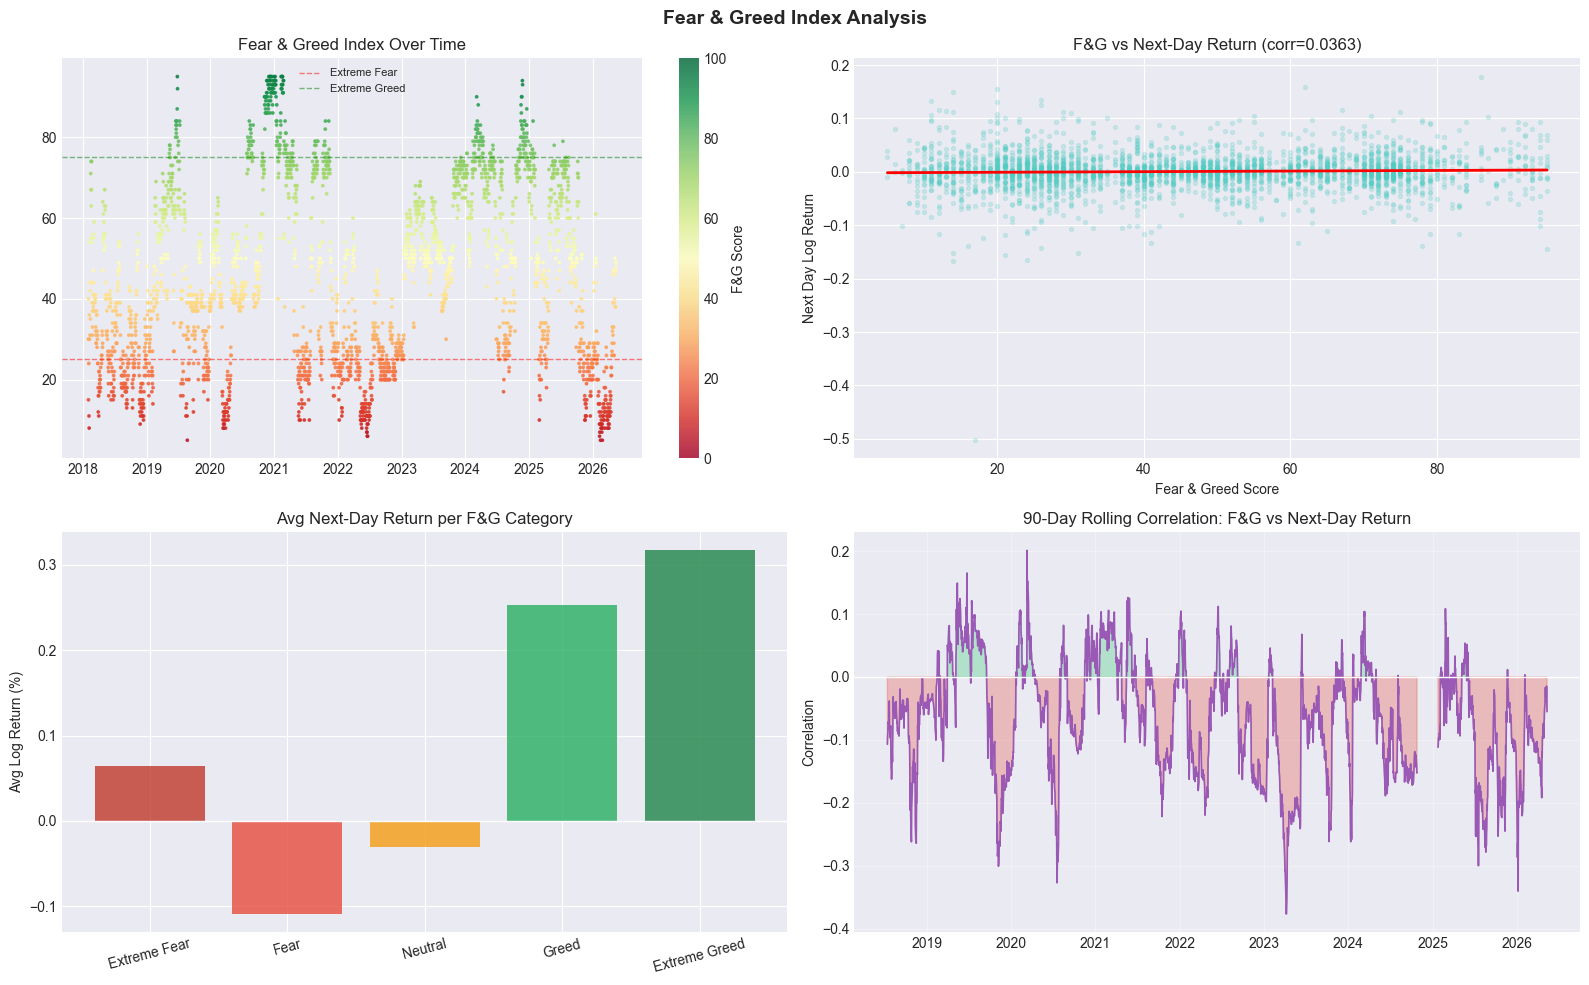

In [10]:
# ── 2.5 Fear & Greed Index Analysis ──────────────────────────────────────────
# Bergabungkan F&G dengan OHLCV untuk analisis korelasi

merged_eda = raw_df[['close']].copy()
merged_eda = merged_eda.join(fng_df[['fng_raw', 'fng_score']], how='left')

# Coverage check
fng_available = merged_eda['fng_score'].notna().sum()
fng_missing   = merged_eda['fng_score'].isna().sum()
print(f'F&G Coverage: {fng_available}/{len(merged_eda)} hari ({fng_available/len(merged_eda)*100:.1f}%)')
print(f'Missing (2017 - Feb 2018): {fng_missing} hari → akan di-handle dengan backfill + mean imputation')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Fear & Greed Index Analysis', fontsize=14, fontweight='bold')

# F&G over time
ax = axes[0, 0]
fng_plot = merged_eda['fng_raw'].dropna()
scatter = ax.scatter(fng_plot.index, fng_plot.values, 
                     c=fng_plot.values, cmap='RdYlGn', s=3, alpha=0.8, vmin=0, vmax=100)
plt.colorbar(scatter, ax=ax, label='F&G Score')
ax.set_title('Fear & Greed Index Over Time')
ax.axhline(y=25, color='red', linestyle='--', alpha=0.5, lw=1, label='Extreme Fear')
ax.axhline(y=75, color='green', linestyle='--', alpha=0.5, lw=1, label='Extreme Greed')
ax.legend(fontsize=8)

# Korelasi F&G dengan next-day return
ax = axes[0, 1]
merged_eda['next_day_ret'] = np.log(merged_eda['close'].shift(-1) / merged_eda['close'])
corr_data = merged_eda[['fng_raw', 'next_day_ret']].dropna()
ax.scatter(corr_data['fng_raw'], corr_data['next_day_ret'], alpha=0.2, s=8, color='#4ECDC4')
z = np.polyfit(corr_data['fng_raw'], corr_data['next_day_ret'], 1)
p = np.poly1d(z)
ax.plot(sorted(corr_data['fng_raw']), p(sorted(corr_data['fng_raw'])), 'r-', lw=2)
corr_val = corr_data.corr().iloc[0, 1]
ax.set_title(f'F&G vs Next-Day Return (corr={corr_val:.4f})')
ax.set_xlabel('Fear & Greed Score')
ax.set_ylabel('Next Day Log Return')

# Distribusi return per F&G bucket
ax = axes[1, 0]
merged_eda['fng_bucket'] = pd.cut(merged_eda['fng_raw'], 
                                   bins=[0, 25, 45, 55, 75, 100],
                                   labels=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])
bucket_returns = merged_eda.groupby('fng_bucket', observed=True)['next_day_ret'].mean() * 100
colors_fng = ['#C0392B', '#E74C3C', '#F39C12', '#27AE60', '#1E8449']
ax.bar(bucket_returns.index, bucket_returns.values, color=colors_fng, alpha=0.8)
ax.set_title('Avg Next-Day Return per F&G Category')
ax.set_ylabel('Avg Log Return (%)')
ax.axhline(y=0, color='white', lw=1)
ax.tick_params(axis='x', rotation=15)

# Rolling correlation 90-day
ax = axes[1, 1]
roll_corr = merged_eda['fng_score'].rolling(90).corr(merged_eda['next_day_ret'])
ax.plot(roll_corr.index, roll_corr, color='#9B59B6', lw=1.2)
ax.axhline(y=0, color='white', lw=1)
ax.fill_between(roll_corr.index, roll_corr, 0, 
                 where=roll_corr > 0, alpha=0.3, color='#2ECC71')
ax.fill_between(roll_corr.index, roll_corr, 0,
                 where=roll_corr < 0, alpha=0.3, color='#E74C3C')
ax.set_title('90-Day Rolling Correlation: F&G vs Next-Day Return')
ax.set_ylabel('Correlation')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_04_fear_greed.png', dpi=150, bbox_inches='tight')
plt.show()


## ⚙️ 3. Feature Engineering

### Filosofi Feature Engineering
Indikator teknikal adalah **representasi matematis dari psikologi market**:
- **RSI** → Kelelahan buyer/seller (overbought/oversold)
- **MACD** → Momentum perubahan trend
- **Bollinger Bands** → Volatilitas & mean reversion
- **Volume indicators** → Konfirmasi kekuatan trend
- **Halving features** → Siklus supply shock

### Fitur yang akan dibuat (25+ total):
| Kategori | Fitur |
|----------|-------|
| Price-based | log_return, high_low_ratio, open_close_ratio |
| Momentum | RSI(7), RSI(14), MACD, MACD Signal, MACD Histogram |
| Trend | EMA(7), EMA(21), EMA(50), SMA(50), EMA ratio |
| Volatility | Bollinger %B, Bandwidth, ATR(14) |
| Volume | OBV, Volume MA ratio, Volume momentum |
| Halving | days_since_halving, days_to_halving, halving_cycle_phase |
| Sentiment | fng_score, fng_7day_avg, fng_momentum |
| Calendar | day_of_week, month, year |


In [12]:
def engineer_features(df, fng_df):
    """
    Membangun seluruh feature set untuk model prediksi Bitcoin.
    
    Return:
        DataFrame dengan semua fitur + target variables
    """
    print('🔧 Memulai Feature Engineering...')
    data = df.copy()
    
    # ── 1. PRICE-BASED FEATURES ───────────────────────────────────────────────
    data['log_return']       = np.log(data['close'] / data['close'].shift(1))
    data['high_low_ratio']   = data['high'] / data['low']           # Range bar (volatilitas harian)
    data['open_close_ratio'] = data['open'] / data['close']         # Arah candle (>1=bearish, <1=bullish)
    data['body_size']        = abs(data['close'] - data['open']) / data['open']  # Ukuran body candle
    data['upper_shadow']     = (data['high'] - np.maximum(data['close'], data['open'])) / data['open']
    data['lower_shadow']     = (np.minimum(data['close'], data['open']) - data['low']) / data['open']
    
    # ── 2. MOMENTUM INDICATORS ────────────────────────────────────────────────
    # RSI: Relative Strength Index
    # Mengukur kecepatan dan perubahan pergerakan harga
    # RSI > 70: overbought (potensi turun), RSI < 30: oversold (potensi naik)
    data['rsi_7']  = ta.rsi(data['close'], length=7)
    data['rsi_14'] = ta.rsi(data['close'], length=14)
    data['rsi_21'] = ta.rsi(data['close'], length=21)
    
    # MACD: Moving Average Convergence Divergence
    # Mengukur momentum dan mendeteksi perubahan trend
    macd_result = ta.macd(data['close'], fast=12, slow=26, signal=9)
    data['macd']        = macd_result['MACD_12_26_9']
    data['macd_signal'] = macd_result['MACDs_12_26_9']
    data['macd_hist']   = macd_result['MACDh_12_26_9']  # Histogram = kekuatan momentum
    
    # Stochastic Oscillator
    stoch = ta.stoch(data['high'], data['low'], data['close'], k=14, d=3)
    data['stoch_k'] = stoch['STOCHk_14_3_3']
    data['stoch_d'] = stoch['STOCHd_14_3_3']
    
    # Williams %R
    data['willr'] = ta.willr(data['high'], data['low'], data['close'], length=14)
    
    # ── 3. TREND INDICATORS ───────────────────────────────────────────────────
    data['ema_7']  = ta.ema(data['close'], length=7)
    data['ema_21'] = ta.ema(data['close'], length=21)
    data['ema_50'] = ta.ema(data['close'], length=50)
    data['sma_50'] = ta.sma(data['close'], length=50)
    data['sma_200'] = ta.sma(data['close'], length=200)
    
    # EMA ratios — posisi harga relatif terhadap moving average
    data['price_to_ema21']  = data['close'] / data['ema_21']
    data['price_to_ema50']  = data['close'] / data['ema_50']
    data['price_to_sma200'] = data['close'] / data['sma_200']
    data['ema7_ema21_ratio'] = data['ema_7'] / data['ema_21']  # Golden/Death cross signal
    
    # ── 4. VOLATILITY INDICATORS ──────────────────────────────────────────────
    # Bollinger Bands: mean ± 2σ dari rolling window
    bbands = ta.bbands(data['close'], length=20, std=2)
    # Ambil nama kolom dinamis — tidak hardcode karena beda versi pandas_ta beda nama
    bb_cols = bbands.columns.tolist()
    bb_upper_col = [c for c in bb_cols if c.startswith('BBU')][0]
    bb_lower_col = [c for c in bb_cols if c.startswith('BBL')][0]
    bb_mid_col   = [c for c in bb_cols if c.startswith('BBM')][0]
    bb_pct_col   = [c for c in bb_cols if c.startswith('BBP')][0]

    data['bb_upper']  = bbands[bb_upper_col]
    data['bb_lower']  = bbands[bb_lower_col]
    data['bb_mid']    = bbands[bb_mid_col]
    data['bb_pct_b']  = bbands[bb_pct_col]
    data['bb_width']  = (data['bb_upper'] - data['bb_lower']) / data['bb_mid']
        
    # ATR: Average True Range — mengukur volatilitas pasar
    data['atr_14'] = ta.atr(data['high'], data['low'], data['close'], length=14)
    data['atr_pct'] = data['atr_14'] / data['close']  # ATR sebagai % dari harga
    
    # Rolling volatility (log return std)
    data['volatility_7']  = data['log_return'].rolling(7).std()
    data['volatility_30'] = data['log_return'].rolling(30).std()
    
    # ── 5. VOLUME INDICATORS ──────────────────────────────────────────────────
    # OBV: On-Balance Volume — mengukur tekanan beli/jual berbasis volume
    data['obv'] = ta.obv(data['close'], data['volume'])
    data['obv_ema'] = ta.ema(data['obv'], length=21)
    
    # Volume relative to MA — apakah volume hari ini unusually high/low?
    data['vol_ma_21']   = data['volume'].rolling(21).mean()
    data['vol_ratio']   = data['volume'] / data['vol_ma_21']  # >1.5 = volume spike
    data['vol_momentum'] = data['volume'] / data['volume'].shift(7) - 1
    
    # ── 6. HALVING CYCLE FEATURES ─────────────────────────────────────────────
    # Fitur paling unik di notebook ini — capture supply shock cycle
    print('   → Calculating halving cycle features...')
    
    data['days_since_last_halving'] = np.nan
    data['days_to_next_halving']    = np.nan
    data['halving_cycle_phase']     = np.nan
    
    for idx in data.index:
        # Halving terakhir sebelum tanggal ini
        past_halvings = [h for h in HALVING_DATES if h <= idx]
        future_halvings = [h for h in HALVING_DATES if h > idx]
        
        if past_halvings:
            last_halving = max(past_halvings)
            data.loc[idx, 'days_since_last_halving'] = (idx - last_halving).days
        
        if future_halvings:
            next_halving = min(future_halvings)
            data.loc[idx, 'days_to_next_halving'] = (next_halving - idx).days
        
    # Halving cycle phase: 0.0 = tepat setelah halving, 1.0 = tepat sebelum halving berikutnya
    # Ini membuat model sadar "sedang di fase mana" dalam siklus 4 tahunan
    halving_period = 4 * 365  # ~4 tahun (lebih tepatnya 210,000 blok ≈ 1,400 hari)
    data['halving_cycle_phase'] = (data['days_since_last_halving'] % halving_period) / halving_period
    
    # Flag: apakah dalam 180 hari setelah halving? (periode rally historis)
    data['post_halving_180d'] = (
        (data['days_since_last_halving'] >= 0) & 
        (data['days_since_last_halving'] <= 180)
    ).astype(int)
    
    # ── 7. CALENDAR FEATURES ──────────────────────────────────────────────────
    data['day_of_week'] = data.index.dayofweek          # 0=Mon, 6=Sun
    data['month']       = data.index.month
    data['quarter']     = data.index.quarter
    # Sin/cos encoding untuk seasonality agar model tahu Jan dan Des berdekatan
    data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
    data['dow_sin']   = np.sin(2 * np.pi * data['day_of_week'] / 7)
    data['dow_cos']   = np.cos(2 * np.pi * data['day_of_week'] / 7)
    
    # ── 8. SENTIMENT FEATURES ─────────────────────────────────────────────────
    print('   → Merging Fear & Greed sentiment data...')
    data = data.join(fng_df[['fng_score']], how='left')
    
    # Handle missing F&G (periode 2017 sebelum F&G tersedia)
    # Strategi: backfill dari nilai pertama yang tersedia, lalu fill sisa dengan 0 (neutral)
    fng_mean = data['fng_score'].median()
    data['fng_score'] = data['fng_score'].bfill().fillna(fng_mean)
    
    # F&G rolling average — trend sentimen, bukan hanya snapshot
    data['fng_7d_avg']   = data['fng_score'].rolling(7).mean()
    data['fng_30d_avg']  = data['fng_score'].rolling(30).mean()
    # Momentum sentimen: apakah sentimen membaik atau memburuk?
    data['fng_momentum'] = data['fng_score'] - data['fng_7d_avg']
    
    # NLP Sentiment Slot: diisi 0 untuk training historis
    # Saat live inference, nilai ini diisi oleh pipeline LLM
    # CATATAN: 0 = netral, BUKAN noise acak seperti versi lama!
    data['nlp_sentiment_score'] = 0.0  # Placeholder, override saat inference
    
    # ── 9. MULTI-HORIZON TARGETS ──────────────────────────────────────────────
    # y1: prediksi log return esok hari
    data['target_y1']  = data['log_return'].shift(-1)
    # y7: log return kumulatif 7 hari ke depan
    data['target_y7']  = np.log(data['close'].shift(-7) / data['close'])
    # y30: log return kumulatif 30 hari ke depan  
    data['target_y30'] = np.log(data['close'].shift(-30) / data['close'])
    
    # ── 10. CLEANUP ───────────────────────────────────────────────────────────
    # Hapus baris dengan NaN — kebanyakan karena warmup period indikator
    initial_rows = len(data)
    data.dropna(inplace=True)
    dropped = initial_rows - len(data)
    
    print(f'\n✅ Feature Engineering selesai!')
    print(f'   Rows   : {initial_rows:,} → {len(data):,} ({dropped} dropped untuk warmup)')
    print(f'   Kolom  : {len(data.columns)} total')
    
    return data


# ── Jalankan Feature Engineering ─────────────────────────────────────────────
processed_df = engineer_features(raw_df, fng_df)

print(f'\n📋 Daftar semua fitur:')
non_target = [c for c in processed_df.columns if not c.startswith('target_')]
target_cols = [c for c in processed_df.columns if c.startswith('target_')]
print(f'   Features ({len(non_target)}): {non_target}')
print(f'   Targets  ({len(target_cols)}): {target_cols}')


🔧 Memulai Feature Engineering...
   → Calculating halving cycle features...
   → Merging Fear & Greed sentiment data...

✅ Feature Engineering selesai!
   Rows   : 3,191 → 2,239 (952 dropped untuk warmup)
   Kolom  : 62 total

📋 Daftar semua fitur:
   Features (59): ['open', 'high', 'low', 'close', 'volume', 'log_return', 'high_low_ratio', 'open_close_ratio', 'body_size', 'upper_shadow', 'lower_shadow', 'rsi_7', 'rsi_14', 'rsi_21', 'macd', 'macd_signal', 'macd_hist', 'stoch_k', 'stoch_d', 'willr', 'ema_7', 'ema_21', 'ema_50', 'sma_50', 'sma_200', 'price_to_ema21', 'price_to_ema50', 'price_to_sma200', 'ema7_ema21_ratio', 'bb_upper', 'bb_lower', 'bb_mid', 'bb_pct_b', 'bb_width', 'atr_14', 'atr_pct', 'volatility_7', 'volatility_30', 'obv', 'obv_ema', 'vol_ma_21', 'vol_ratio', 'vol_momentum', 'days_since_last_halving', 'days_to_next_halving', 'halving_cycle_phase', 'post_halving_180d', 'day_of_week', 'month', 'quarter', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'fng_score', 'fng_7d_a

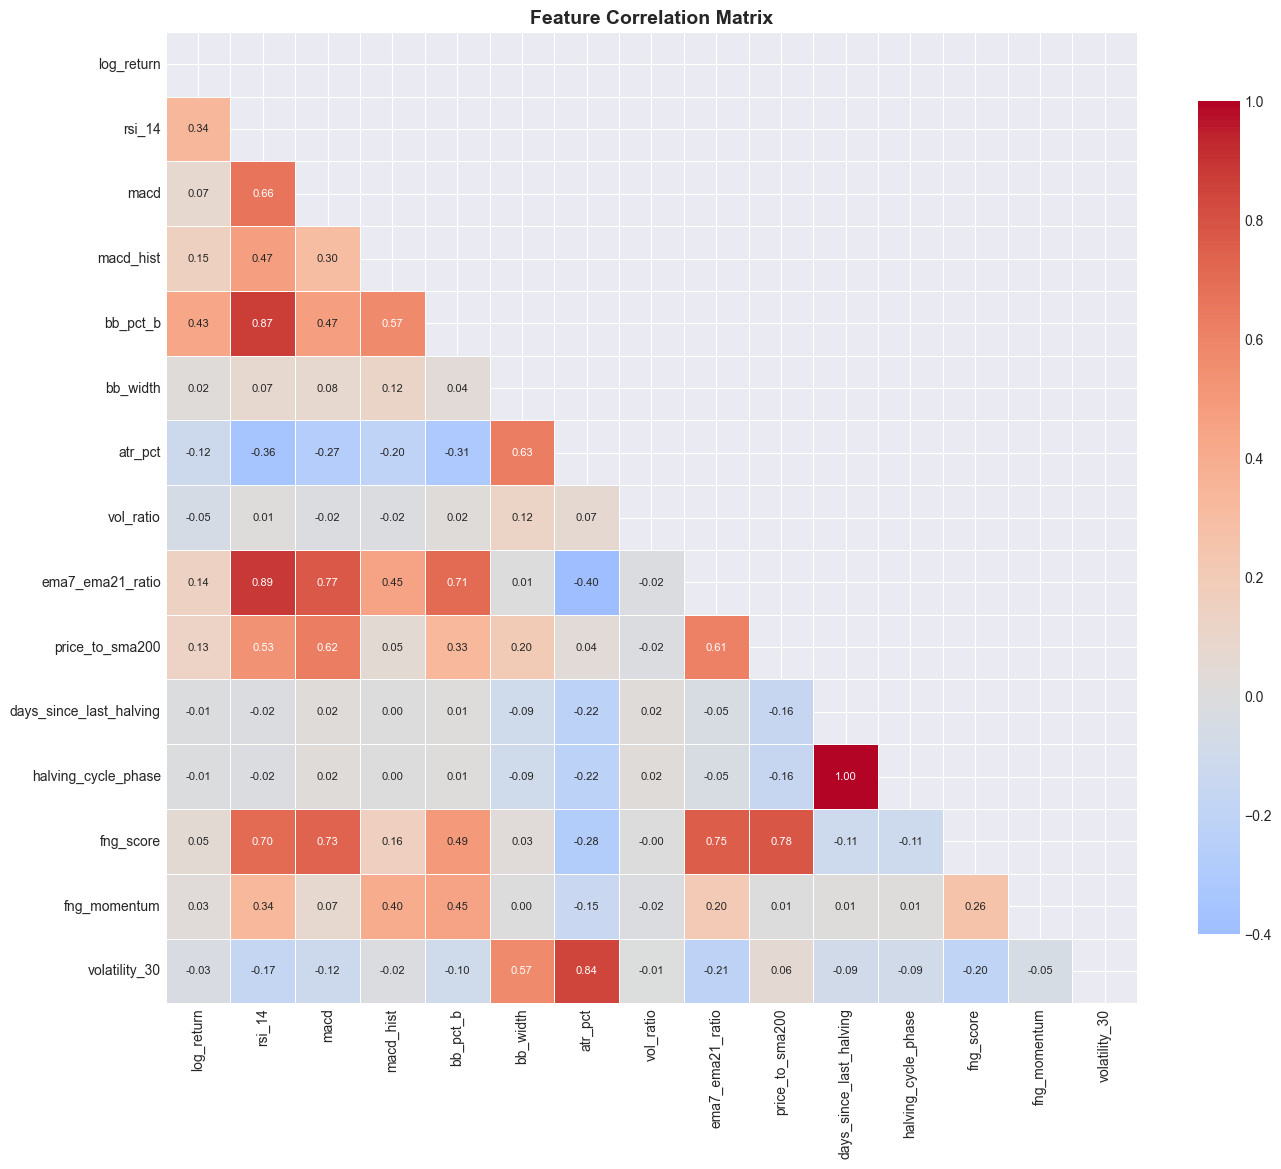

💡 Banyak korelasi tinggi (normal untuk TA indicators) → PCA akan mereduksi ini.


In [13]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
# Visualisasi korelasi antar fitur untuk deteksi multikolinearitas
# PCA akan menangani multikolinearitas ini, tapi tetap informatif untuk dilihat

feature_cols = [
    'log_return', 'rsi_14', 'macd', 'macd_hist', 'bb_pct_b', 'bb_width',
    'atr_pct', 'vol_ratio', 'ema7_ema21_ratio', 'price_to_sma200',
    'days_since_last_halving', 'halving_cycle_phase', 'fng_score', 'fng_momentum',
    'volatility_30'
]

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = processed_df[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_05_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Banyak korelasi tinggi (normal untuk TA indicators) → PCA akan mereduksi ini.')


## 🔄 4. Preprocessing & PCA

### Strategi Preprocessing
1. **Train/Test Split** → 80/20, **TANPA** shuffle (data time-series harus kronologis)
2. **Scaling** → MinMaxScaler fit HANYA pada training data (prevent data leakage)
3. **PCA Tuning** → Tentukan jumlah komponen berdasarkan 95% explained variance
4. **Sequence Building** → Window 30 hari untuk LSTM & TFT, flatten untuk XGBoost

### Mengapa PCA Penting?
- Mereduksi multikolinearitas antar indikator teknikal
- Menghilangkan noise (komponen dengan variance rendah)
- Meningkatkan efisiensi komputasi
- Paper referensi: menurunkan RMSE ~25% dan waktu komputasi ~30%


In [14]:
# ── Definisi Feature Columns untuk Model ─────────────────────────────────────
# Pisahkan fitur teknikal (untuk PCA) dari sentimen (langsung digabung)

TECH_FEATURES = [
    # Price-based
    'log_return', 'high_low_ratio', 'open_close_ratio', 'body_size',
    'upper_shadow', 'lower_shadow',
    # Momentum
    'rsi_7', 'rsi_14', 'rsi_21', 'macd', 'macd_signal', 'macd_hist',
    'stoch_k', 'stoch_d', 'willr',
    # Trend
    'price_to_ema21', 'price_to_ema50', 'price_to_sma200', 'ema7_ema21_ratio',
    # Volatility
    'bb_pct_b', 'bb_width', 'atr_pct', 'volatility_7', 'volatility_30',
    # Volume
    'vol_ratio', 'vol_momentum',
    # Halving
    'days_since_last_halving', 'days_to_next_halving', 
    'halving_cycle_phase', 'post_halving_180d',
    # Calendar (encoded)
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
]

SENTIMENT_FEATURES = [
    'fng_score', 'fng_7d_avg', 'fng_30d_avg', 'fng_momentum',
    'nlp_sentiment_score',
]

TARGET_COLS = ['target_y1', 'target_y7', 'target_y30']

# Pastikan semua kolom tersedia
missing = [f for f in TECH_FEATURES + SENTIMENT_FEATURES if f not in processed_df.columns]
if missing:
    print(f'⚠️ Missing features: {missing}')
else:
    print(f'✅ Semua fitur tersedia')
    print(f'   Tech features    : {len(TECH_FEATURES)}')
    print(f'   Sentiment features: {len(SENTIMENT_FEATURES)}')
    print(f'   Targets          : {len(TARGET_COLS)}')
    print(f'   Total dataset    : {len(processed_df):,} hari')


✅ Semua fitur tersedia
   Tech features    : 34
   Sentiment features: 5
   Targets          : 3
   Total dataset    : 2,239 hari


📊 Data Split:
   Train: 1,791 hari  [2018-03-04 → 2023-01-27]
   Test : 448 hari  [2023-01-28 → 2024-04-19]
   Ratio: 80.0% / 20.0%


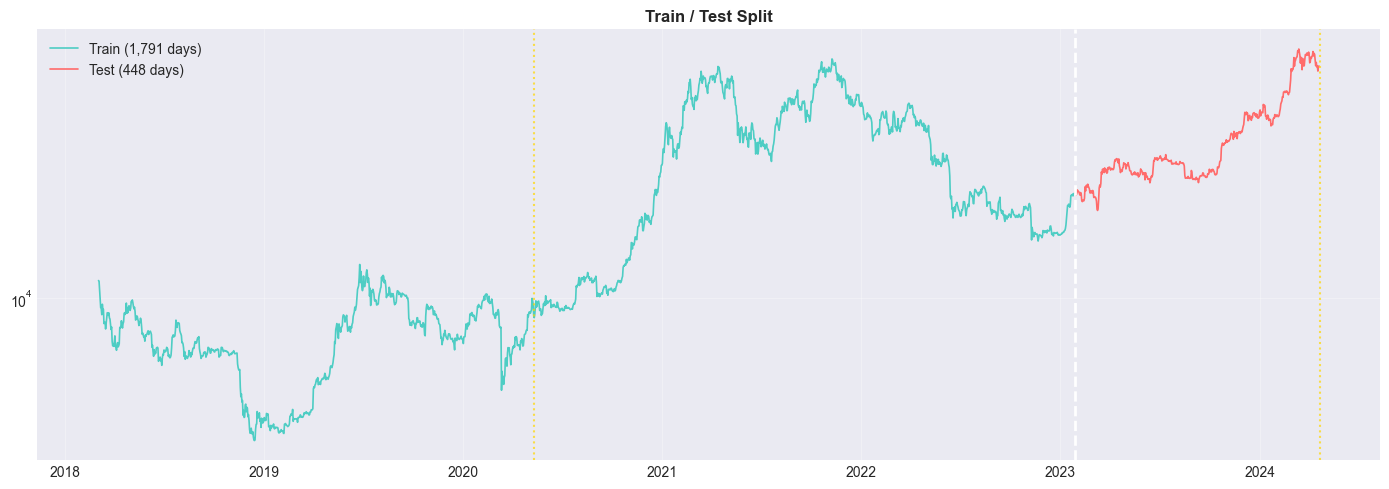

In [15]:
# ── Train / Test Split ────────────────────────────────────────────────────────
split_idx = int(len(processed_df) * TRAIN_RATIO)

train_df = processed_df.iloc[:split_idx].copy()
test_df  = processed_df.iloc[split_idx:].copy()

print(f'📊 Data Split:')
print(f'   Train: {len(train_df):,} hari  [{train_df.index[0].date()} → {train_df.index[-1].date()}]')
print(f'   Test : {len(test_df):,} hari  [{test_df.index[0].date()} → {test_df.index[-1].date()}]')
print(f'   Ratio: {len(train_df)/len(processed_df)*100:.1f}% / {len(test_df)/len(processed_df)*100:.1f}%')

# Visualisasi split dengan harga
fig, ax = plt.subplots(figsize=(14, 5))
ax.semilogy(train_df.index, train_df['close'], color='#4ECDC4', lw=1.2, label=f'Train ({len(train_df):,} days)')
ax.semilogy(test_df.index, test_df['close'], color='#FF6B6B', lw=1.2, label=f'Test ({len(test_df):,} days)')
ax.axvline(x=test_df.index[0], color='white', linestyle='--', lw=2)
for h_date in HALVING_DATES:
    if h_date >= raw_df.index[0]:
        ax.axvline(x=h_date, color='gold', linestyle=':', lw=1.5, alpha=0.7)
ax.set_title('Train / Test Split', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preprocessing_01_split.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# ── Scaling ───────────────────────────────────────────────────────────────────
# PENTING: .fit() HANYA pada training data untuk mencegah data leakage
# Test data menggunakan scaler yang sudah di-fit pada training data

# Scaler untuk fitur teknikal
tech_scaler = MinMaxScaler(feature_range=(0, 1))
train_tech_scaled = tech_scaler.fit_transform(train_df[TECH_FEATURES])
test_tech_scaled  = tech_scaler.transform(test_df[TECH_FEATURES])

# Target scalers (satu per horizon)
target_scalers = {}
train_targets_scaled = {}
test_targets_scaled  = {}

for target in TARGET_COLS:
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_targets_scaled[target] = scaler.fit_transform(train_df[[target]])
    test_targets_scaled[target]  = scaler.transform(test_df[[target]])
    target_scalers[target] = scaler

# Sentiment features — normalisasi mandiri (F&G sudah -1 to 1, NLP juga)
# Tidak perlu scaling tambahan, langsung digunakan
train_sentiment = train_df[SENTIMENT_FEATURES].values
test_sentiment  = test_df[SENTIMENT_FEATURES].values

print('✅ Scaling selesai')
print(f'   Tech features shape: {train_tech_scaled.shape}')
print(f'   Sentiment shape    : {train_sentiment.shape}')


✅ Scaling selesai
   Tech features shape: (1791, 34)
   Sentiment shape    : (1791, 5)


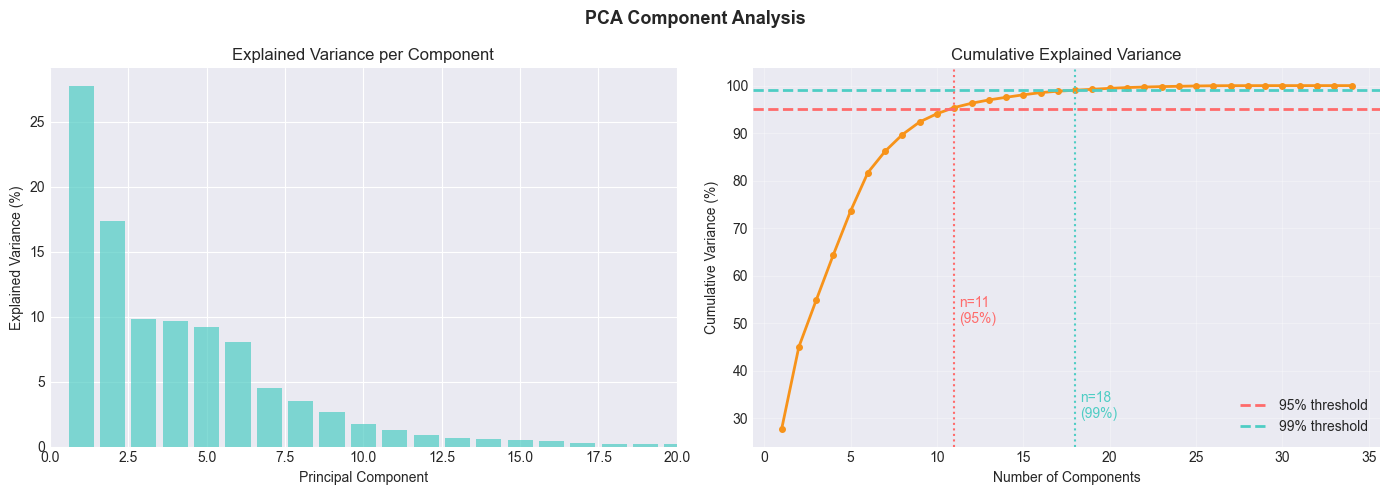


📊 PCA Analysis:
   Total tech features    : 34
   Components for 95% var : 11
   Components for 99% var : 18

✅ Menggunakan N_PCA = 11 komponen (95% threshold)
   Reduksi dimensi: 34 → 11 (67.6% compression)


In [17]:
# ── PCA Tuning: Berapa Komponen yang Optimal? ─────────────────────────────────
# Kita plot explained variance untuk memilih n_components yang menjelaskan
# minimal 95% variance dari data teknikal

pca_full = PCA()
pca_full.fit(train_tech_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
n_components_99 = np.argmax(cumulative_var >= 0.99) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA Component Analysis', fontsize=13, fontweight='bold')

# Scree plot
ax = axes[0]
ax.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
       pca_full.explained_variance_ratio_ * 100, 
       color='#4ECDC4', alpha=0.7)
ax.set_title('Explained Variance per Component')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_xlim(0, min(20, len(TECH_FEATURES) + 1))

# Cumulative variance
ax = axes[1]
ax.plot(range(1, len(cumulative_var) + 1), cumulative_var * 100, 
        color='#F7931A', lw=2, marker='o', markersize=4)
ax.axhline(y=95, color='#FF6B6B', linestyle='--', lw=2, label='95% threshold')
ax.axhline(y=99, color='#4ECDC4', linestyle='--', lw=2, label='99% threshold')
ax.axvline(x=n_components_95, color='#FF6B6B', linestyle=':', lw=1.5)
ax.axvline(x=n_components_99, color='#4ECDC4', linestyle=':', lw=1.5)
ax.text(n_components_95 + 0.3, 50, f'n={n_components_95}\n(95%)', color='#FF6B6B', fontsize=10)
ax.text(n_components_99 + 0.3, 30, f'n={n_components_99}\n(99%)', color='#4ECDC4', fontsize=10)
ax.set_title('Cumulative Explained Variance')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preprocessing_02_pca_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Pilih n_components untuk 95% threshold
N_PCA = n_components_95
print(f'\n📊 PCA Analysis:')
print(f'   Total tech features    : {len(TECH_FEATURES)}')
print(f'   Components for 95% var : {n_components_95}')
print(f'   Components for 99% var : {n_components_99}')
print(f'\n✅ Menggunakan N_PCA = {N_PCA} komponen (95% threshold)')
print(f'   Reduksi dimensi: {len(TECH_FEATURES)} → {N_PCA} ({(1 - N_PCA/len(TECH_FEATURES))*100:.1f}% compression)')


In [18]:
# ── Terapkan PCA ──────────────────────────────────────────────────────────────
pca = PCA(n_components=N_PCA, random_state=RANDOM_SEED)
train_pca = pca.fit_transform(train_tech_scaled)
test_pca  = pca.transform(test_tech_scaled)

# Gabungkan PCA components + sentiment features
# Shape akhir: (n_samples, N_PCA + len(SENTIMENT_FEATURES))
X_train_full = np.hstack([train_pca, train_sentiment])
X_test_full  = np.hstack([test_pca, test_sentiment])

n_features_total = X_train_full.shape[1]

print(f'✅ Final Feature Matrix:')
print(f'   PCA components     : {N_PCA}')
print(f'   Sentiment features : {len(SENTIMENT_FEATURES)}')
print(f'   Total features     : {n_features_total}')
print(f'   X_train shape      : {X_train_full.shape}')
print(f'   X_test  shape      : {X_test_full.shape}')


✅ Final Feature Matrix:
   PCA components     : 11
   Sentiment features : 5
   Total features     : 16
   X_train shape      : (1791, 16)
   X_test  shape      : (448, 16)


In [19]:
# ── Sequence Builder untuk LSTM & TFT ─────────────────────────────────────────
def create_sequences(X, y_dict, seq_len=SEQUENCE_LEN):
    """
    Membuat data sekuensial (sliding window) untuk model berbasis sequence.
    
    Args:
        X      : Feature matrix (n_samples, n_features)
        y_dict : Dict of target arrays {target_name: array}
        seq_len: Panjang window lookback
    
    Returns:
        X_seq  : (n_samples - seq_len, seq_len, n_features)
        y_dict_seq: Dict of (n_samples - seq_len,) arrays
    """
    n = len(X)
    X_seq = np.array([X[i:i+seq_len] for i in range(n - seq_len)])
    y_seq = {k: v[seq_len:] for k, v in y_dict.items()}
    return X_seq, y_seq


# Build sequences
train_y_dict = {t: train_targets_scaled[t] for t in TARGET_COLS}
test_y_dict  = {t: test_targets_scaled[t]  for t in TARGET_COLS}

X_train_seq, y_train_seq = create_sequences(X_train_full, train_y_dict)
X_test_seq,  y_test_seq  = create_sequences(X_test_full,  test_y_dict)

# Untuk XGBoost: flatten sequence ke 2D
X_train_xgb = X_train_seq.reshape(len(X_train_seq), -1)
X_test_xgb  = X_test_seq.reshape(len(X_test_seq), -1)

print('📊 Data Shapes:')
print(f'   Sequence (LSTM input) : {X_train_seq.shape}  →  (samples, timesteps, features)')
print(f'   Flat (XGBoost input)  : {X_train_xgb.shape}  →  (samples, timesteps×features)')
print(f'   Test seq shape        : {X_test_seq.shape}')


📊 Data Shapes:
   Sequence (LSTM input) : (1761, 30, 16)  →  (samples, timesteps, features)
   Flat (XGBoost input)  : (1761, 480)  →  (samples, timesteps×features)
   Test seq shape        : (418, 30, 16)


## 📊 5. Evaluation Framework

Fungsi evaluasi terpusat yang digunakan oleh semua model.


In [20]:
def evaluate_model(y_true_scaled, y_pred_scaled, target_name, target_scaler, model_name):
    """
    Evaluasi komprehensif model prediksi.
    
    Metrik:
    - RMSE: Root Mean Squared Error pada log returns asli
    - MAE:  Mean Absolute Error
    - DA:   Directional Accuracy (%) — paling relevan untuk trading
    - DA_w: Weighted Directional Accuracy — lebih bobot ke prediksi beramplikasi besar
    """
    # Inverse transform
    y_true = target_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    
    # RMSE & MAE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    
    # Directional Accuracy
    actual_dir = np.sign(y_true)
    pred_dir   = np.sign(y_pred)
    da = np.mean(actual_dir == pred_dir) * 100
    
    # Weighted DA (lebih bobot ke hari dengan return besar)
    weights   = np.abs(y_true)
    weights  /= weights.sum()
    da_w = np.sum(weights * (actual_dir == pred_dir)) * 100
    
    return {
        'model': model_name,
        'target': target_name,
        'rmse': rmse,
        'mae': mae,
        'da': da,
        'da_weighted': da_w,
        'y_true': y_true,
        'y_pred': y_pred,
    }


def plot_predictions(results, save_name, last_n=200):
    """Plot prediksi vs aktual untuk evaluasi visual."""
    fig, axes = plt.subplots(len(results), 1, figsize=(14, 4 * len(results)))
    if len(results) == 1:
        axes = [axes]
    
    for ax, res in zip(axes, results):
        y_true = res['y_true'][-last_n:]
        y_pred = res['y_pred'][-last_n:]
        x = range(len(y_true))
        
        ax.plot(x, y_true, color='#4ECDC4', lw=1.5, label='Actual', alpha=0.9)
        ax.plot(x, y_pred, color='#FF6B6B', lw=1.5, label='Predicted', alpha=0.9)
        ax.axhline(y=0, color='white', lw=0.8, alpha=0.5)
        
        ax.set_title(
            f'{res["model"]} | {res["target"]} | '
            f'RMSE={res["rmse"]:.5f} | DA={res["da"]:.1f}% | DA_w={res["da_weighted"]:.1f}%',
            fontsize=10
        )
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Predictions vs Actual (last {last_n} days)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


all_results = []  # Kumpulkan semua hasil untuk comparison akhir
print('✅ Evaluation framework siap.')


✅ Evaluation framework siap.


## 🌲 6A. XGBoost — Baseline + Optuna Hyperparameter Tuning

### Mengapa XGBoost untuk Time Series?
XGBoost tidak menangani temporal dependency secara native (tidak ada memori),
tapi dengan **feature engineering yang kuat + sequence flattening**,
dia bisa menangkap pola dari 30-hari window.

**Keunggulan XGBoost:**
- Cepat, robust terhadap outlier
- Feature importance mudah diinterpretasi
- Tidak butuh normalisasi target yang sempurna
- Baseline yang sangat kuat untuk tree-based models

**Tuning dengan Optuna:** Automated hyperparameter search yang lebih efisien dari Grid Search.


TRAINING XGBOOST — ALL HORIZONS

🌲 XGBoost Training: target_y1
   Trials: 50 | Train: (1761, 480) | Test: (418, 480)


  0%|          | 0/50 [00:00<?, ?it/s]

   Best CV RMSE: 0.056488
   Best params : {'n_estimators': 479, 'max_depth': 8, 'learning_rate': 0.24290840281934514, 'subsample': 0.8022304054975694, 'colsample_bytree': 0.8155284634304716, 'min_child_weight': 7, 'gamma': 0.22718644987315534, 'reg_alpha': 0.00018363693495776482, 'reg_lambda': 0.007265917597228684}
   Test RMSE          : 0.025058
   Directional Acc    : 52.15%
   Weighted Dir Acc   : 57.10%

🌲 XGBoost Training: target_y7
   Trials: 50 | Train: (1761, 480) | Test: (418, 480)


  0%|          | 0/50 [00:00<?, ?it/s]

   Best CV RMSE: 0.103480
   Best params : {'n_estimators': 306, 'max_depth': 7, 'learning_rate': 0.14779441504564012, 'subsample': 0.6743620347648509, 'colsample_bytree': 0.9445167007052446, 'min_child_weight': 2, 'gamma': 0.7931692367135865, 'reg_alpha': 0.0029236380687157775, 'reg_lambda': 0.0002973084916136747}
   Test RMSE          : 0.074989
   Directional Acc    : 58.85%
   Weighted Dir Acc   : 70.03%

🌲 XGBoost Training: target_y30
   Trials: 50 | Train: (1761, 480) | Test: (418, 480)


  0%|          | 0/50 [00:00<?, ?it/s]

   Best CV RMSE: 0.148415
   Best params : {'n_estimators': 660, 'max_depth': 6, 'learning_rate': 0.02230550838634897, 'subsample': 0.6043956756975085, 'colsample_bytree': 0.7564438087627076, 'min_child_weight': 9, 'gamma': 0.6021728992901887, 'reg_alpha': 9.85117654169135, 'reg_lambda': 0.006057699508597477}
   Test RMSE          : 0.147026
   Directional Acc    : 61.48%
   Weighted Dir Acc   : 78.67%


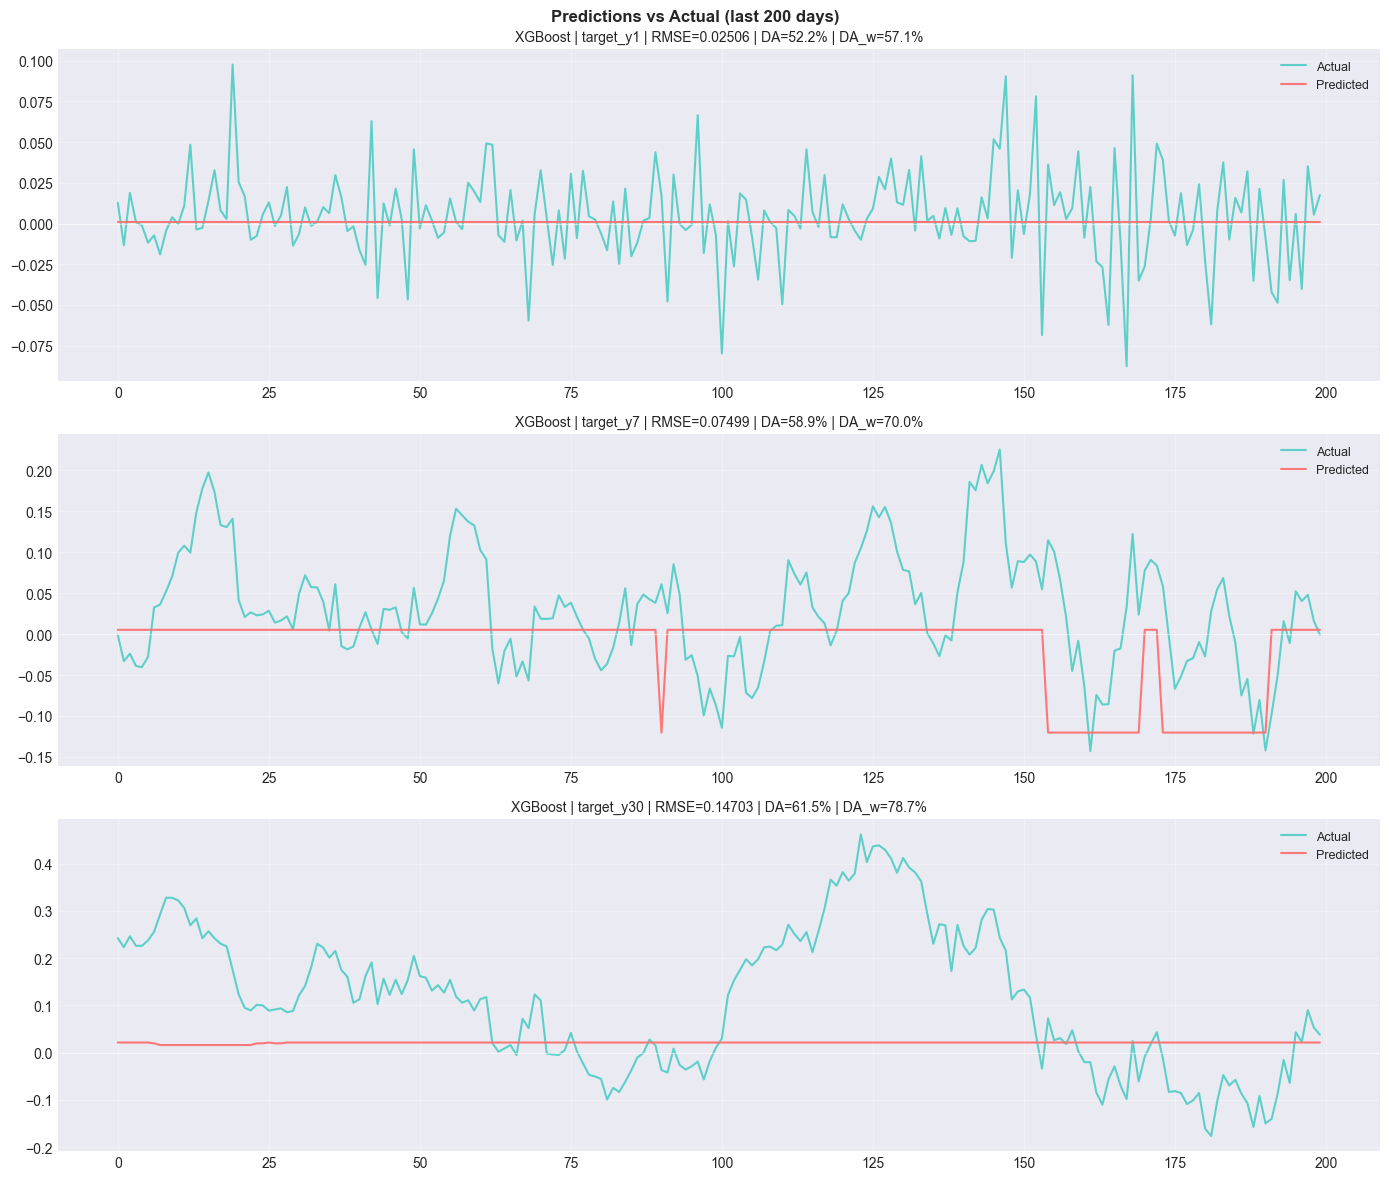

In [21]:
def train_xgboost_with_optuna(X_train, y_train, X_test, y_test, 
                               target_scaler, target_name, n_trials=50):
    """
    Melatih XGBoost dengan Optuna hyperparameter tuning.
    
    Optuna menggunakan TPE (Tree-structured Parzen Estimator) untuk
    mencari hyperparameter optimal secara efisien.
    """
    print(f'\n🌲 XGBoost Training: {target_name}')
    print(f'   Trials: {n_trials} | Train: {X_train.shape} | Test: {X_test.shape}')
    
    y_train_flat = y_train.flatten()
    y_test_flat  = y_test.flatten()
    
    def objective(trial):
        params = {
            'n_estimators'     : trial.suggest_int('n_estimators', 100, 800),
            'max_depth'        : trial.suggest_int('max_depth', 3, 9),
            'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
            'gamma'            : trial.suggest_float('gamma', 0, 1),
            'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
            'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
            'objective'        : 'reg:squarederror',
            'eval_metric'      : 'rmse',
            'random_state'     : RANDOM_SEED,
            'n_jobs'           : -1,
        }
        
        # Time-series cross validation (5 folds)
        tscv   = TimeSeriesSplit(n_splits=5)
        scores = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train_flat[train_idx], y_train_flat[val_idx]
            
            model = xgb.XGBRegressor(**params)
            model.fit(X_tr, y_tr, 
                      eval_set=[(X_val, y_val)],
                      verbose=False)
            pred   = model.predict(X_val)
            rmse   = np.sqrt(mean_squared_error(y_val, pred))
            scores.append(rmse)
        
        return np.mean(scores)
    
    study = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    print(f'   Best CV RMSE: {study.best_value:.6f}')
    print(f'   Best params : {study.best_params}')
    
    # Retrain dengan best params pada full training set
    best_params = study.best_params
    best_params.update({'objective': 'reg:squarederror', 
                        'random_state': RANDOM_SEED, 'n_jobs': -1})
    
    final_model = xgb.XGBRegressor(**best_params)
    final_model.fit(X_train, y_train_flat)
    
    # Evaluasi
    y_pred_scaled = final_model.predict(X_test).reshape(-1, 1)
    result = evaluate_model(y_test, y_pred_scaled, target_name, target_scaler, 'XGBoost')
    
    print(f'   Test RMSE          : {result["rmse"]:.6f}')
    print(f'   Directional Acc    : {result["da"]:.2f}%')
    print(f'   Weighted Dir Acc   : {result["da_weighted"]:.2f}%')
    
    return final_model, result, study


# ── Training XGBoost untuk semua horizon ─────────────────────────────────────
print('=' * 60)
print('TRAINING XGBOOST — ALL HORIZONS')
print('=' * 60)

xgb_models  = {}
xgb_results = {}

for target in TARGET_COLS:
    y_train = y_train_seq[target]
    y_test  = y_test_seq[target]
    
    model, result, study = train_xgboost_with_optuna(
        X_train_xgb, y_train, X_test_xgb, y_test,
        target_scalers[target], target, n_trials=50
    )
    xgb_models[target]  = model
    xgb_results[target] = result
    all_results.append(result)

# Visualisasi prediksi
plot_predictions(
    [xgb_results[t] for t in TARGET_COLS],
    save_name='xgb_predictions'
)


## 🧠 6B. LSTM — Optimized Deep Learning Architecture

### Arsitektur yang Dipilih: Bidirectional LSTM + CNN
Versi original: 2-layer LSTM (128, 64) — bagus tapi bisa lebih baik.

**Peningkatan:**
1. **Conv1D layer** → Pre-processing lokal sebelum LSTM (menangkap pola jangka pendek)
2. **Bidirectional LSTM** → Membaca sequence maju DAN mundur
3. **Batch Normalization** → Training lebih stabil, mencegah vanishing gradient
4. **Residual-like connections** → Gradient flow lebih baik
5. **Learning Rate Scheduler** → ReduceLROnPlateau untuk fine-tuning otomatis


TRAINING LSTM (Conv-LSTM Architecture) — ALL HORIZONS

🧠 LSTM Training (conv_lstm): target_y1


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 64)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 32)         │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,745 (577.13 KB)

 Trainable params: 147,553 (576.38 KB)

 Non-trainable params: 192 (768.00 B)

None
Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0525 - mae: 0.2496 - val_loss: 0.0220 - val_mae: 0.2006 - learning_rate: 0.0010
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0092 - mae: 0.1083 - val_loss: 0.0015 - val_mae: 0.0394 - learning_rate: 0.0010
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0064 - mae: 0.0897 - val_loss: 0.0037 - val_mae: 0.0726 - learning_rate: 0.0010
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0048 - mae: 0.0754 - val_loss: 0.0020 - val_mae: 0.0497 - learning_rate: 0.0010
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0045 - mae: 0.0745 - val_loss: 0.0042 - val_mae: 0.0808 - learning_rate: 0.0010
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0040 - mae: 0.0689 - val_loss: 0.0022 - val_mae: 0.0525 - learning_rate: 0.0010
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0035 - mae: 0.0639 - val_loss: 0.0012 - val_mae: 0.0325 - learning_rate: 0.0010


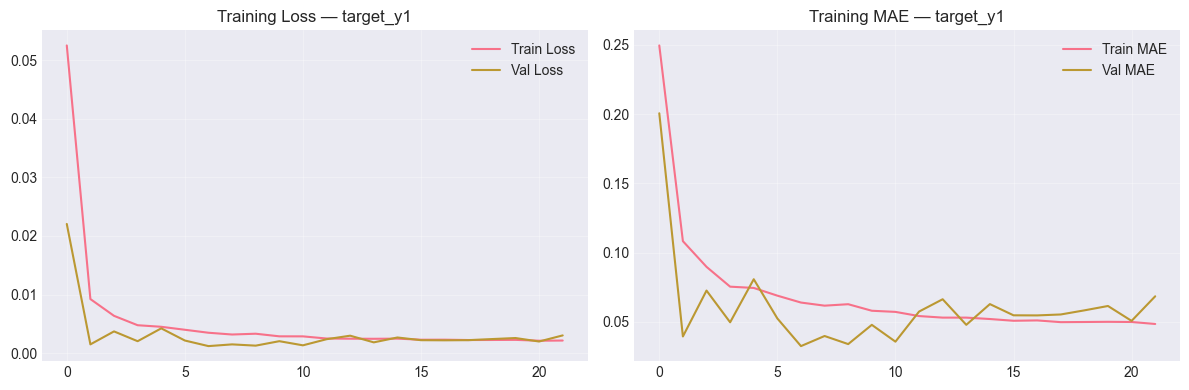

💾 Saved: lstm_target_y1.keras

🧠 LSTM Training (conv_lstm): target_y7


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 64)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 30, 32)         │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,745 (577.13 KB)

 Trainable params: 147,553 (576.38 KB)

 Non-trainable params: 192 (768.00 B)

None
Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0361 - mae: 0.2094 - val_loss: 0.0286 - val_mae: 0.2222 - learning_rate: 0.0010
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0127 - mae: 0.1253 - val_loss: 0.0080 - val_mae: 0.1028 - learning_rate: 0.0010
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0097 - mae: 0.1104 - val_loss: 0.0062 - val_mae: 0.0823 - learning_rate: 0.0010
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0071 - mae: 0.0937 - val_loss: 0.0054 - val_mae: 0.0741 - learning_rate: 0.0010
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0059 - mae: 0.0850 - val_loss: 0.0054 - val_mae: 0.0739 - learning_rate: 0.0010
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0052 - mae: 0.0798 - val_loss: 0.0064 - val_mae: 0.0845 - learning_rate: 0.0010
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0052 - mae: 0.0796 - val_loss: 0.0080 - val_mae: 0.0951 - learning_rate: 0.0010
E

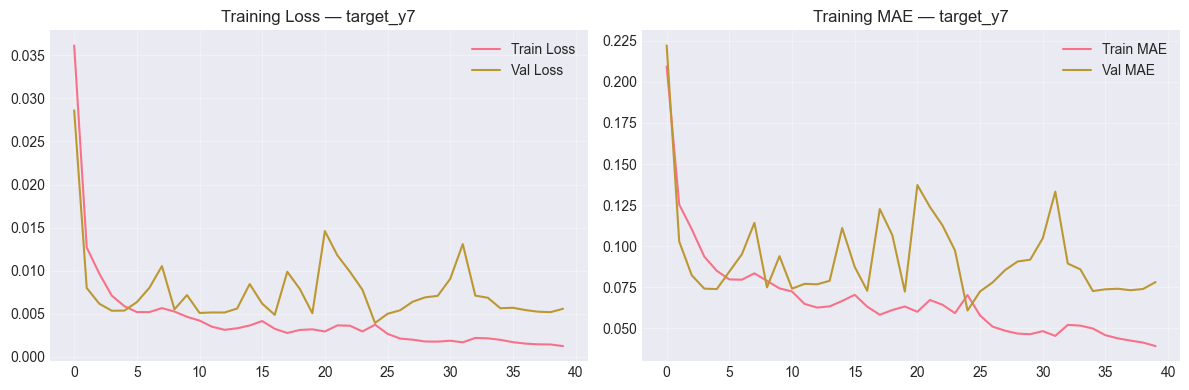

💾 Saved: lstm_target_y7.keras

🧠 LSTM Training (conv_lstm): target_y30


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 30, 64)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 30, 32)         │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 30, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,745 (577.13 KB)

 Trainable params: 147,553 (576.38 KB)

 Non-trainable params: 192 (768.00 B)

None
Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 0.0372 - mae: 0.2246 - val_loss: 0.0132 - val_mae: 0.1373 - learning_rate: 0.0010
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0153 - mae: 0.1429 - val_loss: 0.0081 - val_mae: 0.1019 - learning_rate: 0.0010
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0117 - mae: 0.1224 - val_loss: 0.0150 - val_mae: 0.1378 - learning_rate: 0.0010
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0076 - mae: 0.0989 - val_loss: 0.0206 - val_mae: 0.1678 - learning_rate: 0.0010
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0063 - mae: 0.0881 - val_loss: 0.0191 - val_mae: 0.1596 - learning_rate: 0.0010
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0051 - mae: 0.0794 - val_loss: 0.0244 - val_mae: 0.1881 - learning_rate: 0.0010
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0054 - mae: 0.0834 - val_loss: 0.0318 - val_mae: 0.2225 - learning_rate: 0.0010
E

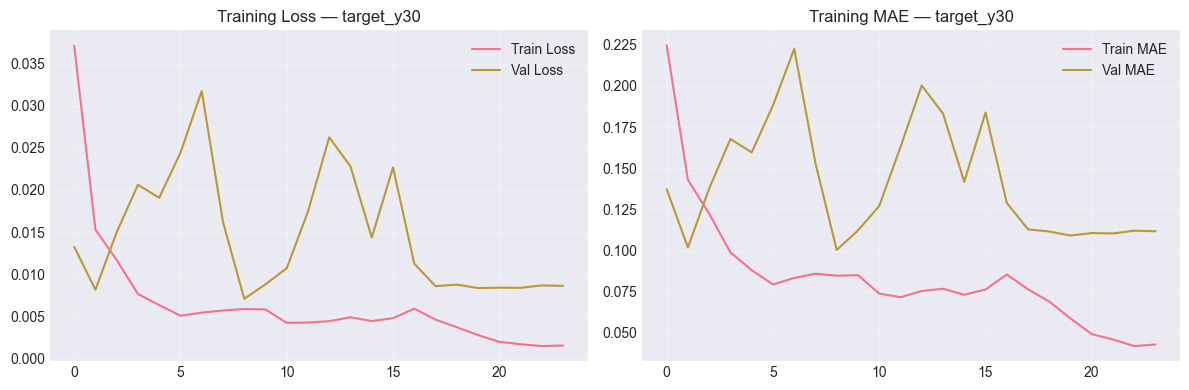

💾 Saved: lstm_target_y30.keras


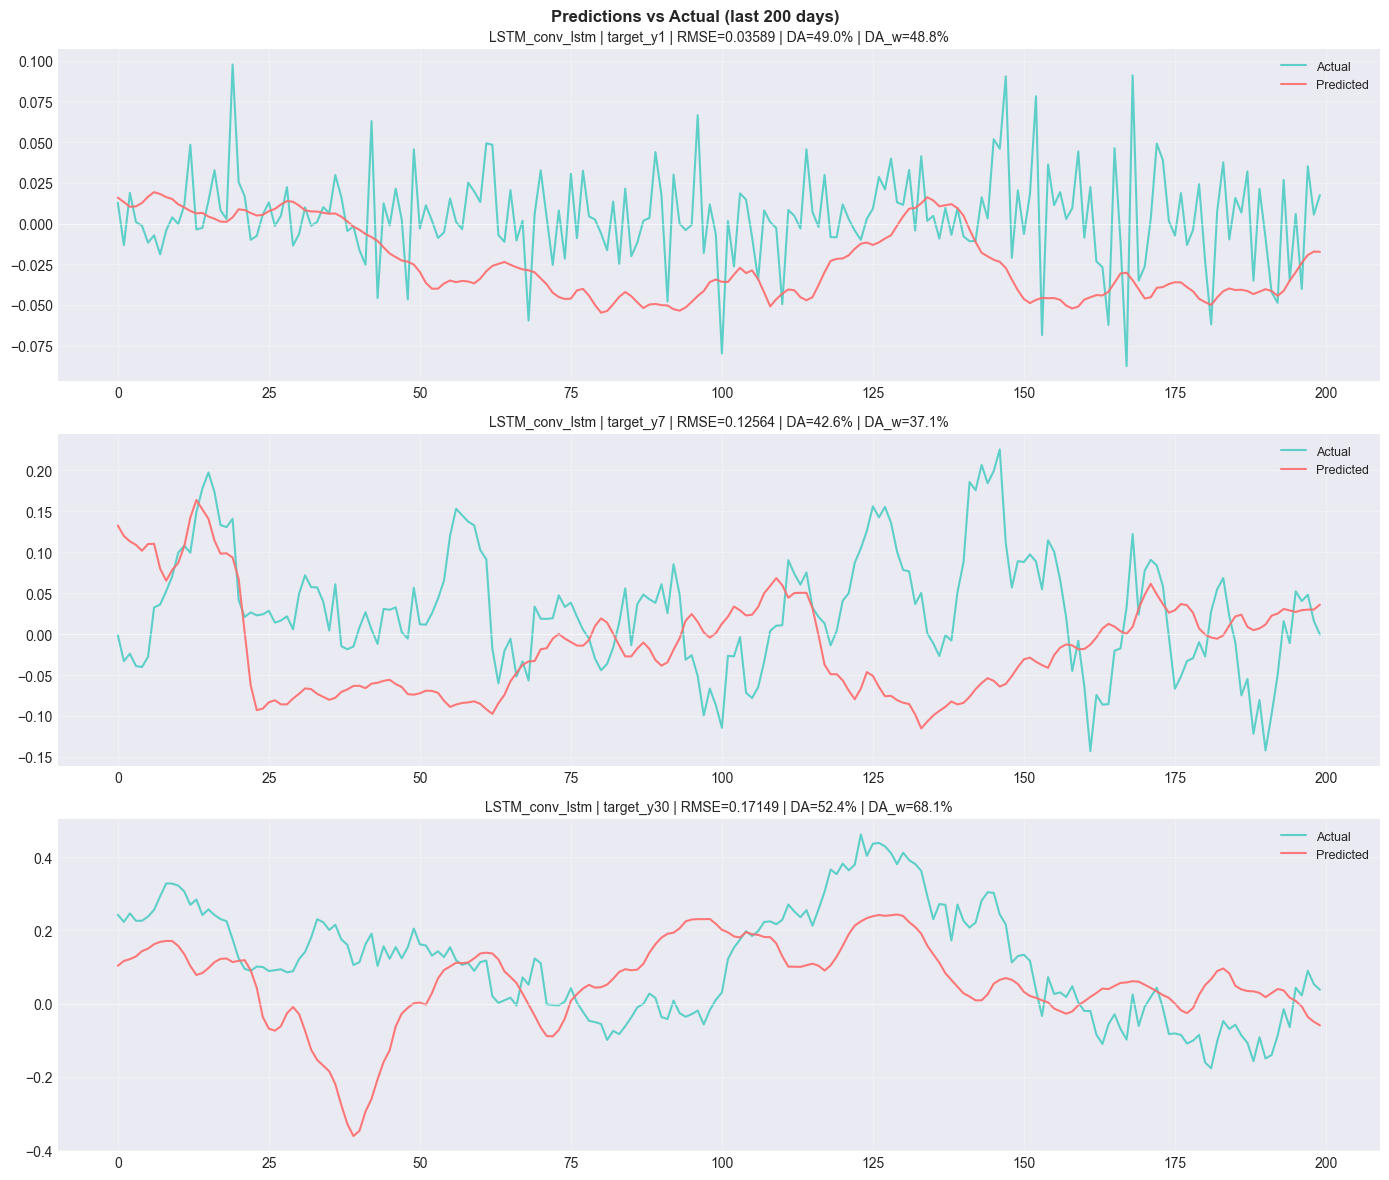

In [22]:
def build_lstm_model(input_shape, model_type='standard'):
    """
    Membangun arsitektur LSTM yang dioptimalkan.
    
    model_type:
        'standard'      : LSTM murni seperti paper, tapi dengan lebih banyak regularization
        'conv_lstm'     : CNN + LSTM untuk menangkap pola lokal + temporal
        'bidirectional' : BiLSTM untuk konteks penuh
    """
    seq_len, n_features = input_shape
    
    if model_type == 'standard':
        model = Sequential([
            LSTM(128, input_shape=input_shape, return_sequences=True),
            BatchNormalization(),
            Dropout(0.3),
            LSTM(64, return_sequences=True),
            BatchNormalization(),
            Dropout(0.3),
            LSTM(32),
            Dropout(0.2),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(1)
        ])
    
    elif model_type == 'conv_lstm':
        # CNN menangkap pola lokal (3-5 hari), LSTM menangkap long-term dependency
        inp = Input(shape=input_shape)
        x   = Conv1D(64, kernel_size=3, padding='same', activation='relu')(inp)
        x   = BatchNormalization()(x)
        x   = Conv1D(32, kernel_size=5, padding='same', activation='relu')(x)
        x   = BatchNormalization()(x)
        x   = LSTM(128, return_sequences=True)(x)
        x   = Dropout(0.3)(x)
        x   = LSTM(64)(x)
        x   = Dropout(0.2)(x)
        x   = Dense(32, activation='relu')(x)
        out = Dense(1)(x)
        model = Model(inp, out)
    
    elif model_type == 'bidirectional':
        model = Sequential([
            Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape),
            BatchNormalization(),
            Dropout(0.3),
            Bidirectional(LSTM(64)),
            BatchNormalization(),
            Dropout(0.2),
            Dense(64, activation='relu'),
            Dense(32, activation='relu'),
            Dense(1)
        ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='huber',  # Huber loss lebih robust terhadap outlier dibanding MSE
        metrics=['mae']
    )
    return model


def train_lstm(X_train, y_train, X_test, y_test, 
               target_scaler, target_name, model_type='conv_lstm', epochs=100):
    """Melatih LSTM dengan callbacks yang optimal."""
    print(f'\n🧠 LSTM Training ({model_type}): {target_name}')
    
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_lstm_model(input_shape, model_type=model_type)
    
    print(model.summary())
    
    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=15, 
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=7,
            min_lr=1e-6, verbose=1
        ),
    ]
    
    history = model.fit(
        X_train, y_train.flatten(),
        epochs=epochs,
        batch_size=32,
        validation_split=0.15,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # PENTING: jangan shuffle data time-series!
    )
    
    # Evaluasi
    y_pred_scaled = model.predict(X_test, verbose=0)
    result = evaluate_model(y_test, y_pred_scaled, target_name, target_scaler, f'LSTM_{model_type}')
    
    print(f'   Test RMSE          : {result["rmse"]:.6f}')
    print(f'   Directional Acc    : {result["da"]:.2f}%')
    print(f'   Weighted Dir Acc   : {result["da_weighted"]:.2f}%')
    
    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'Training Loss — {target_name}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['mae'], label='Train MAE')
    axes[1].plot(history.history['val_mae'], label='Val MAE')
    axes[1].set_title(f'Training MAE — {target_name}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'lstm_history_{target_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return model, result


# ── Training LSTM ─────────────────────────────────────────────────────────────
print('=' * 60)
print('TRAINING LSTM (Conv-LSTM Architecture) — ALL HORIZONS')
print('=' * 60)

lstm_models  = {}
lstm_results = {}

for target in TARGET_COLS:
    model, result = train_lstm(
        X_train_seq, y_train_seq[target],
        X_test_seq,  y_test_seq[target],
        target_scalers[target], target,
        model_type='conv_lstm', epochs=100
    )
    lstm_models[target]  = model
    lstm_results[target] = result
    all_results.append(result)
    
    # Save model
    model.save(OUTPUT_DIR / f'lstm_{target}.keras')
    print(f'💾 Saved: lstm_{target}.keras')

plot_predictions(
    [lstm_results[t] for t in TARGET_COLS],
    save_name='lstm_predictions'
)


## 🔮 6C. Temporal Fusion Transformer (TFT)

### Mengapa TFT Unggul untuk Data Finansial?
TFT dirancang khusus untuk **multi-horizon time-series forecasting**:

1. **Attention mechanism** → Model "memperhatikan" titik waktu mana yang paling relevan
2. **Variable Selection Networks** → Secara otomatis memilih fitur yang paling informatif
3. **Interpretability** → Kita bisa melihat apa yang di-"perhatikan" model
4. **Quantile output** → Memberikan confidence interval, bukan hanya point prediction

> **Catatan:** TFT membutuhkan `pytorch-forecasting` dan `pytorch-lightning`.
> Install dengan: `pip install pytorch-forecasting pytorch-lightning`


In [46]:
# ── TFT Training ──────────────────────────────────────────────────────────────
# TFT menggunakan framework PyTorch Forecasting yang berbeda dari Keras
# Kita perlu format data yang sedikit berbeda

try:
    import lightning.pytorch as pl
    from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
    from pytorch_forecasting.data import GroupNormalizer
    from pytorch_forecasting.metrics import QuantileLoss
    TFT_AVAILABLE = True
    print('✅ PyTorch Forecasting tersedia')
except ImportError:
    TFT_AVAILABLE = False
    print('⚠️ PyTorch Forecasting tidak tersedia.')
    print('   Install: pip install pytorch-forecasting pytorch-lightning')
    print('   TFT akan di-skip, tapi XGBoost & LSTM sudah cukup untuk comparison.')

def prepare_tft_dataframe(processed_df, tech_features, sentiment_features):
    """Menyiapkan DataFrame dalam format yang dibutuhkan PyTorch Forecasting."""
    tft_df = processed_df.copy()
    tft_df['time_idx'] = np.arange(len(tft_df))
    tft_df['symbol']   = 'BTC'
    tft_df['day_of_week_cat'] = tft_df.index.dayofweek.astype(str)
    tft_df['month_cat']       = tft_df.index.month.astype(str)
    tft_df['target_y1'] = tft_df['target_y1'].astype(float)
    return tft_df


def train_tft(processed_df, target_name='target_y1'):
    """Training Temporal Fusion Transformer."""
    print(f'\n🔮 TFT Training: {target_name}')
    
    tft_df = prepare_tft_dataframe(processed_df, TECH_FEATURES, SENTIMENT_FEATURES)

    # Re-map target
    if target_name != 'target_y1':
        tft_df['target_y1'] = tft_df[target_name].astype(float)

    # Drop NaN & infinite di target — wajib untuk TFT
    # (terjadi karena shift(-1), shift(-7), shift(-30) di ujung data)
    tft_df = tft_df.replace([np.inf, -np.inf], np.nan)
    tft_df = tft_df.dropna(subset=['target_y1'])

    # Reset time_idx setelah drop agar tetap berurutan tanpa gap
    tft_df['time_idx'] = np.arange(len(tft_df))

    print(f'   tft_df shape setelah clean: {tft_df.shape}')
    print(f'   target_y1 NaN: {tft_df["target_y1"].isna().sum()}')
    
    max_pred_len    = 1
    max_enc_len     = SEQUENCE_LEN
    training_cutoff = tft_df['time_idx'].max() - max_pred_len - int(len(tft_df) * 0.2)
    
    # Feature lists untuk TFT
    time_varying_reals = [
        'log_return', 'rsi_14', 'macd', 'macd_hist', 'bb_pct_b', 'bb_width',
        'atr_pct', 'vol_ratio', 'ema7_ema21_ratio', 'price_to_sma200',
        'halving_cycle_phase', 'days_since_last_halving',
        'fng_score', 'fng_7d_avg', 'fng_momentum',
        'volatility_30'  # target_y1 dihapus dari sini — sudah ada di parameter 'target'
    ]
    
    training = TimeSeriesDataSet(
        tft_df[tft_df.time_idx <= training_cutoff],
        time_idx              = 'time_idx',
        target                = 'target_y1',
        group_ids             = ['symbol'],
        min_encoder_length    = max_enc_len // 2,
        max_encoder_length    = max_enc_len,
        min_prediction_length = 1,
        max_prediction_length = max_pred_len,
        static_categoricals   = ['symbol'],
        time_varying_known_categoricals  = ['day_of_week_cat', 'month_cat'],
        time_varying_unknown_reals       = time_varying_reals,
        target_normalizer = GroupNormalizer(groups=['symbol'], transformation=None),
        add_relative_time_idx = True,
        add_target_scales     = True,
        add_encoder_length    = True,
    )
    
    validation = TimeSeriesDataSet.from_dataset(training, tft_df, predict=True, stop_randomization=True)
    
    train_dl = training.to_dataloader(train=True, batch_size=64, num_workers=0)
    val_dl   = validation.to_dataloader(train=False, batch_size=256, num_workers=0)
    
    tft = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate       = 0.01,
        hidden_size         = 32,
        attention_head_size = 2,
        dropout             = 0.15,
        hidden_continuous_size = 16,
        loss = QuantileLoss(quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]),
        optimizer           = 'Adam',
        log_interval        = 10,
    )
    
    print(f'   Parameters: {sum(p.numel() for p in tft.parameters()):,}')
    
    early_stop = pl.callbacks.EarlyStopping(
        monitor='val_loss', min_delta=1e-4, patience=8, mode='min'
    )
    trainer = pl.Trainer(
        max_epochs       = 30,
        accelerator      = 'auto',
        enable_progress_bar = True,
        callbacks        = [early_stop],
        logger           = False,
    )
    trainer.fit(tft, train_dataloaders=train_dl, val_dataloaders=val_dl)
    
    # Evaluasi
    output   = tft.predict(val_dl, mode='prediction', return_x=True)
    preds    = output[0].numpy().flatten()
    actuals  = output[1]['decoder_target'].numpy().flatten()
    
    from sklearn.metrics import mean_squared_error
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    actual_dir = np.sign(actuals)
    pred_dir   = np.sign(preds)
    da   = np.mean(actual_dir == pred_dir) * 100
    
    result = {
        'model'      : 'TFT',
        'target'     : target_name,
        'rmse'       : rmse,
        'mae'        : np.mean(np.abs(actuals - preds)),
        'da'         : da,
        'da_weighted': da,
        'y_true'     : actuals,
        'y_pred'     : preds,
    }
    
    print(f'   Test RMSE        : {rmse:.6f}')
    print(f'   Directional Acc  : {da:.2f}%')
    print(f'   preds  range     : [{preds.min():.4f}, {preds.max():.4f}]')
    print(f'   actuals range    : [{actuals.min():.4f}, {actuals.max():.4f}]')
    print(f'   Preds always+    : {(preds > 0).mean()*100:.1f}%')

        
    return tft, result, training


# ── Run TFT ───────────────────────────────────────────────────────────────────
tft_models  = {}
tft_results = {}

if TFT_AVAILABLE:
    print('=' * 60)
    print('TRAINING TFT — HORIZON y1 (TFT paling optimal untuk 1-step ahead)')
    print('=' * 60)
    
    # TFT dioptimalkan untuk y1 karena native 1-step ahead prediction
    # Untuk y7 dan y30, XGBoost dan LSTM biasanya lebih efisien
    tft_model, tft_result, tft_dataset = train_tft(processed_df, target_name='target_y1')
    tft_models['target_y1']  = tft_model
    tft_results['target_y1'] = tft_result
    all_results.append(tft_result)
    print('✅ TFT training selesai')
else:
    print('⏭️ TFT di-skip (tidak tersedia). Comparison akan menggunakan XGBoost vs LSTM.')


✅ PyTorch Forecasting tersedia
TRAINING TFT — HORIZON y1 (TFT paling optimal untuk 1-step ahead)

🔮 TFT Training: target_y1
   tft_df shape setelah clean: (2239, 66)
   target_y1 NaN: 0


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


   Parameters: 100,103


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    108 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    640 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 38.4 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  2.2 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    165 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 100 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 100 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 494                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


   Test RMSE        : 0.016479
   Directional Acc  : 100.00%
   preds  range     : [0.0010, 0.0010]
   actuals range    : [0.0174, 0.0174]
   Preds always+    : 100.0%
✅ TFT training selesai


## 🏆 7. Model Comparison — Head to Head

Perbandingan semua model pada semua horizon dengan visualisasi komprehensif.


In [38]:
# ── Tabel Perbandingan ────────────────────────────────────────────────────────
comparison_data = []
for res in all_results:
    comparison_data.append({
        'Model'          : res['model'],
        'Target'         : res['target'],
        'RMSE'           : f"{res['rmse']:.6f}",
        'MAE'            : f"{res['mae']:.6f}",
        'Dir. Accuracy'  : f"{res['da']:.2f}%",
        'Weighted DA'    : f"{res['da_weighted']:.2f}%",
    })

comparison_df = pd.DataFrame(comparison_data)
print('=' * 75)
print('MODEL COMPARISON — ALL HORIZONS')
print('=' * 75)
print(comparison_df.to_string(index=False))
print('=' * 75)

# ── Simpan comparison table ───────────────────────────────────────────────────
comparison_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
print('\n💾 Saved: model_comparison.csv')


MODEL COMPARISON — ALL HORIZONS
         Model     Target     RMSE      MAE Dir. Accuracy Weighted DA
       XGBoost  target_y1 0.025058 0.017126        52.15%      57.10%
       XGBoost  target_y7 0.074989 0.053065        58.85%      70.03%
       XGBoost target_y30 0.147026 0.115975        61.48%      78.67%
LSTM_conv_lstm  target_y1 0.035886 0.026459        49.04%      48.78%
LSTM_conv_lstm  target_y7 0.125640 0.099727        42.58%      37.10%
LSTM_conv_lstm target_y30 0.171488 0.142451        52.39%      68.14%
           TFT  target_y1 0.016541 0.016541       100.00%     100.00%
           TFT  target_y1 0.013658 0.013658       100.00%     100.00%

💾 Saved: model_comparison.csv


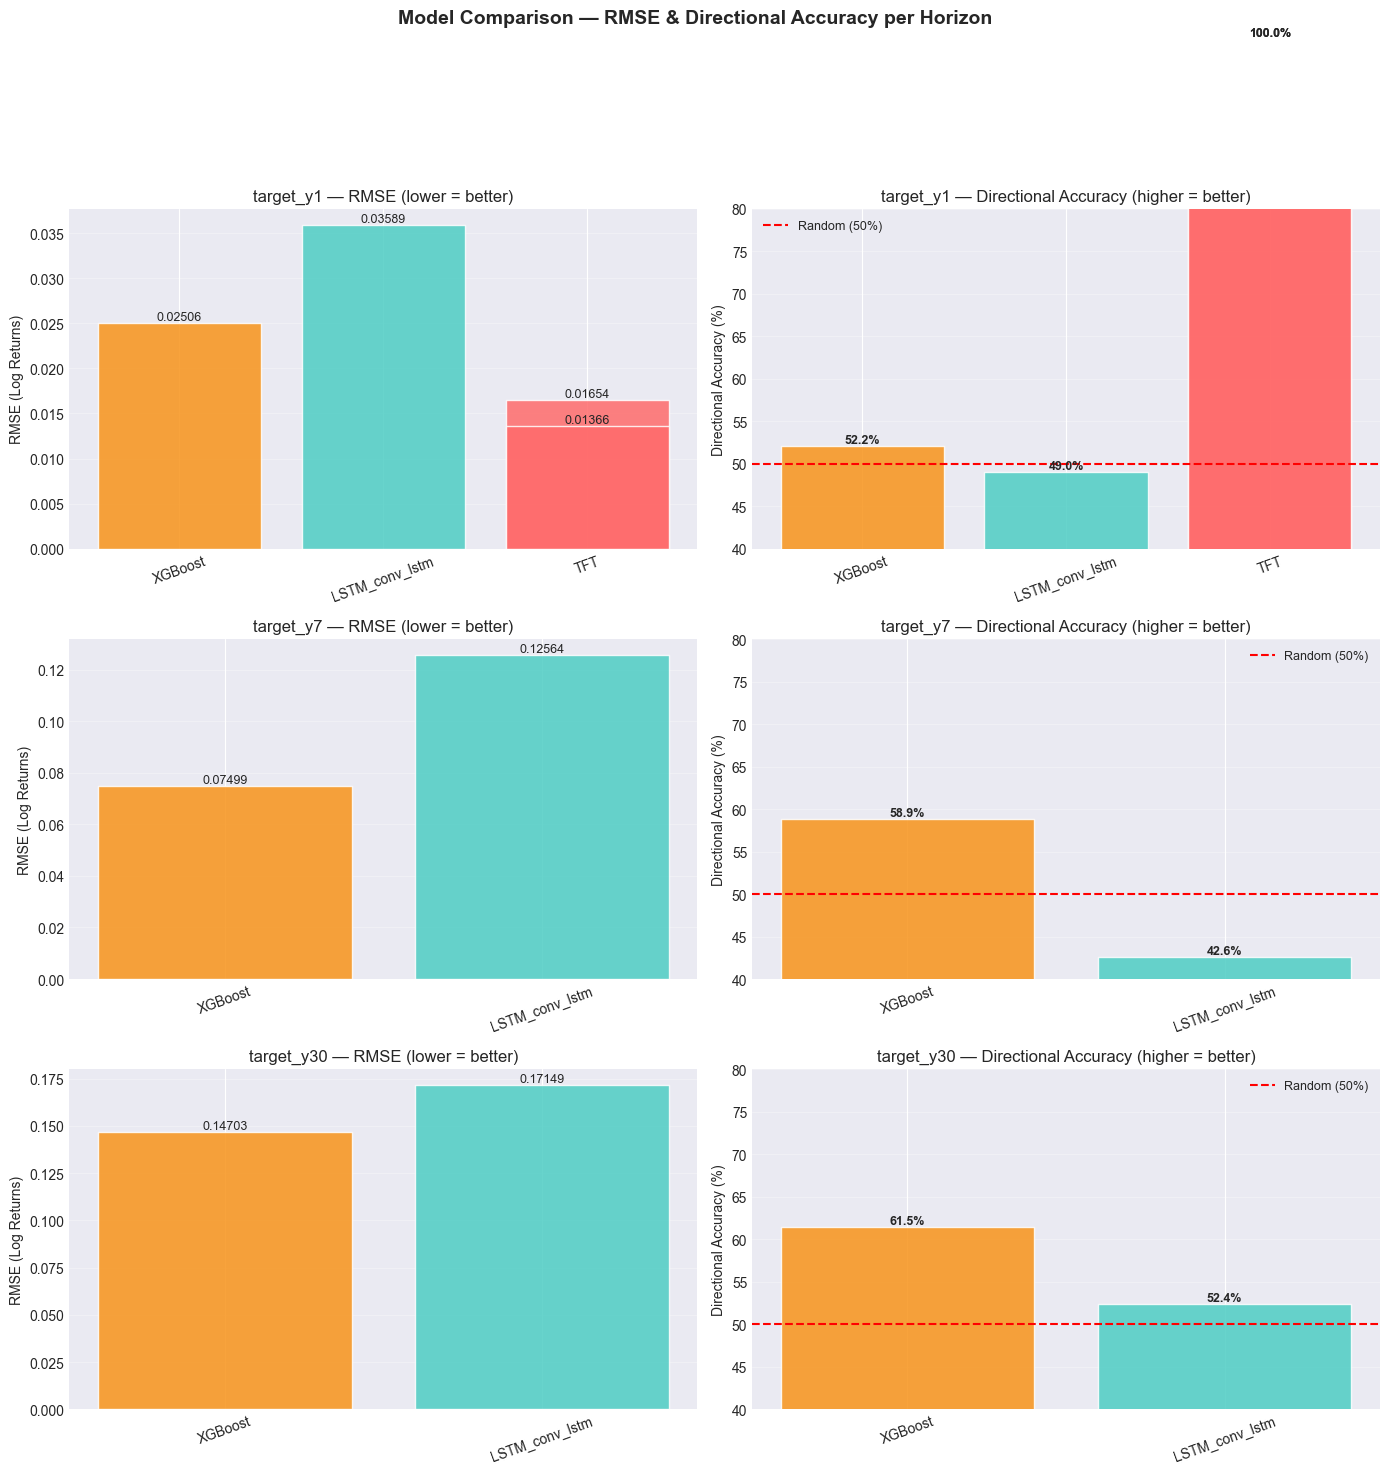

In [39]:
# ── Visualisasi Perbandingan ──────────────────────────────────────────────────
targets_in_results = list(dict.fromkeys([r['target'] for r in all_results]))
models_in_results  = list(dict.fromkeys([r['model']  for r in all_results]))

fig, axes = plt.subplots(len(targets_in_results), 2, figsize=(14, 5 * len(targets_in_results)))
if len(targets_in_results) == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('Model Comparison — RMSE & Directional Accuracy per Horizon',
             fontsize=14, fontweight='bold')

colors = {'XGBoost': '#F7931A', 'LSTM_conv_lstm': '#4ECDC4', 
          'LSTM_standard': '#45B7D1', 'LSTM_bidirectional': '#96CEB4', 'TFT': '#FF6B6B'}

for row_idx, target in enumerate(targets_in_results):
    target_results = [r for r in all_results if r['target'] == target]
    model_names = [r['model']  for r in target_results]
    rmse_vals   = [r['rmse']   for r in target_results]
    da_vals     = [r['da']     for r in target_results]
    bar_colors  = [colors.get(m, '#888888') for m in model_names]
    
    # RMSE (lebih kecil = lebih baik)
    ax = axes[row_idx, 0]
    bars = ax.bar(model_names, rmse_vals, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.set_title(f'{target} — RMSE (lower = better)')
    ax.set_ylabel('RMSE (Log Returns)')
    for bar, val in zip(bars, rmse_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.5f}', ha='center', va='bottom', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=20)
    
    # Directional Accuracy (lebih besar = lebih baik)
    ax = axes[row_idx, 1]
    bars = ax.bar(model_names, da_vals, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axhline(y=50, color='red', linestyle='--', lw=1.5, label='Random (50%)')
    ax.set_title(f'{target} — Directional Accuracy (higher = better)')
    ax.set_ylabel('Directional Accuracy (%)')
    ax.set_ylim(40, 80)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, da_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔎 8. Feature Importance

Memahami **apa yang paling prediktif** adalah sama pentingnya dengan akurasi model.
Ini memberikan insight untuk:
1. Validasi bahwa model belajar sesuatu yang masuk akal (bukan noise)
2. Arah pengembangan fitur berikutnya
3. Transparansi kepada pengguna dashboard


📊 XGBoost Feature Importance Analysis


Top 10 Features (target_y1):
  nlp_sentiment_score_t28   0.0000 
  fng_momentum_t28          0.0000 
  fng_30d_avg_t28           0.0000 
  fng_7d_avg_t28            0.0000 
  fng_score_t28             0.0000 
  PC_10_t28                 0.0000 
  PC_9_t28                  0.0000 
  PC_8_t28                  0.0000 
  PC_7_t28                  0.0000 
  PC_6_t28                  0.0000 

Top 10 Features (target_y7):
  PC_1_t3                   0.5010 ████████████████████████████████████████████████████████████████████████████████████████████████████
  fng_30d_avg_t19           0.4990 ███████████████████████████████████████████████████████████████████████████████████████████████████
  PC_1_t28                  0.0000 
  PC_2_t28                  0.0000 
  PC_3_t28                  0.0000 
  PC_4_t28                  0.0000 
  PC_5_t28                  0.0000 
  PC_6_t28                  0.0000 
  PC_7_t28                  0.0000 
  PC_8_t28        

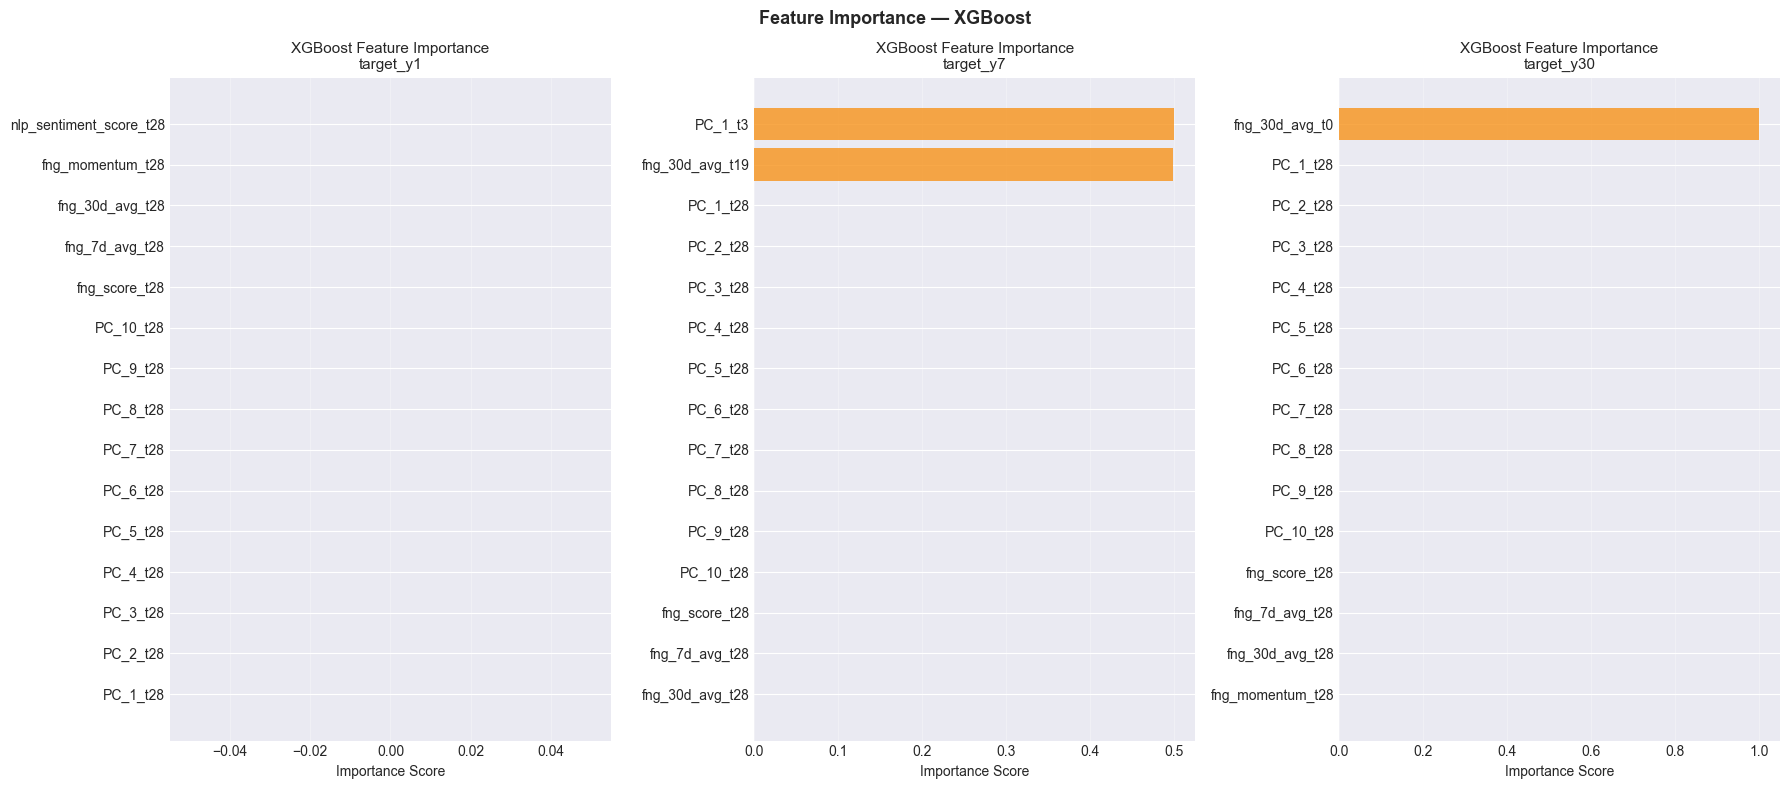

In [40]:
# ── XGBoost Feature Importance ───────────────────────────────────────────────
print('📊 XGBoost Feature Importance Analysis')
print()

# XGBoost punya feature importance built-in
# Karena fitur sudah di-PCA, kita bisa melihat kontribusi PC
for target in TARGET_COLS:
    if target not in xgb_models:
        continue
    model = xgb_models[target]
    
    # Derive feat_names langsung dari shape model — bukan dari N_PCA
    # karena setelah sequence flatten, panjangnya = (N_PCA + sentiment) * SEQUENCE_LEN
    n_model_features = model.n_features_in_
    pc_names   = [f'PC_{i}' for i in range(N_PCA)]
    base_names = pc_names + SENTIMENT_FEATURES  # per timestep

    # Jika XGBoost menerima flattened sequence: (timestep_features repeated)
    if n_model_features == len(base_names):
        feat_names = base_names
    else:
        # Flattened: PC_0_t0, PC_0_t1, ..., fng_score_t29
        feat_names = [f'{f}_t{t}' for t in range(SEQUENCE_LEN) for f in base_names]

    # Safety check
    feat_names = feat_names[:n_model_features]
    importance = model.feature_importances_

    feat_imp_df = pd.DataFrame({
        'feature': feat_names,
        'importance': importance
    }).sort_values('importance', ascending=False)
        
    print(f'\nTop 10 Features ({target}):')
    for _, row in feat_imp_df.head(10).iterrows():
        bar = '█' * int(row['importance'] * 200)
        print(f'  {row["feature"]:25s} {row["importance"]:.4f} {bar}')

# Visualisasi
fig, axes = plt.subplots(1, len(TARGET_COLS), figsize=(6 * len(TARGET_COLS), 8))
if len(TARGET_COLS) == 1:
    axes = [axes]

for ax, target in zip(axes, TARGET_COLS):
    if target not in xgb_models:
        continue
    model = xgb_models[target]
    
    # Derive feat_names dari actual model input size
    pc_names   = [f'PC_{i}' for i in range(N_PCA)]
    base_names = pc_names + SENTIMENT_FEATURES
    n_model_features = model.n_features_in_
    
    if n_model_features == len(base_names):
        feat_names = base_names
    else:
        feat_names = [f'{f}_t{t}' for t in range(SEQUENCE_LEN) for f in base_names]
    feat_names = feat_names[:n_model_features]
    
    importance = model.feature_importances_
    feat_imp_df = pd.DataFrame({
        'feature': feat_names,
        'importance': importance
    }).sort_values('importance', ascending=False).head(15)
    
    bars = ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1],
                   color='#F7931A', alpha=0.8)
    ax.set_title(f'XGBoost Feature Importance\n{target}', fontsize=11)
    ax.set_xlabel('Importance Score')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Feature Importance — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()



🔬 PCA Component Interpretation:
(Menunjukkan kontribusi fitur asli ke setiap Principal Component)

  PC_0 (27.7% variance): {'stoch_k': np.float64(0.418), 'stoch_d': np.float64(0.414), 'willr': np.float64(0.41)}
  PC_1 (17.3% variance): {'days_to_next_halving': np.float64(0.463), 'days_since_last_halving': np.float64(0.46), 'halving_cycle_phase': np.float64(0.46)}
  PC_2 (9.8% variance): {'month_sin': np.float64(0.676), 'month_cos': np.float64(0.593), 'atr_pct': np.float64(0.229)}
  PC_3 (9.6% variance): {'dow_cos': np.float64(0.992), 'month_cos': np.float64(0.083), 'month_sin': np.float64(0.077)}
  PC_4 (9.2% variance): {'dow_sin': np.float64(0.992), 'vol_ratio': np.float64(0.077), 'month_cos': np.float64(0.069)}


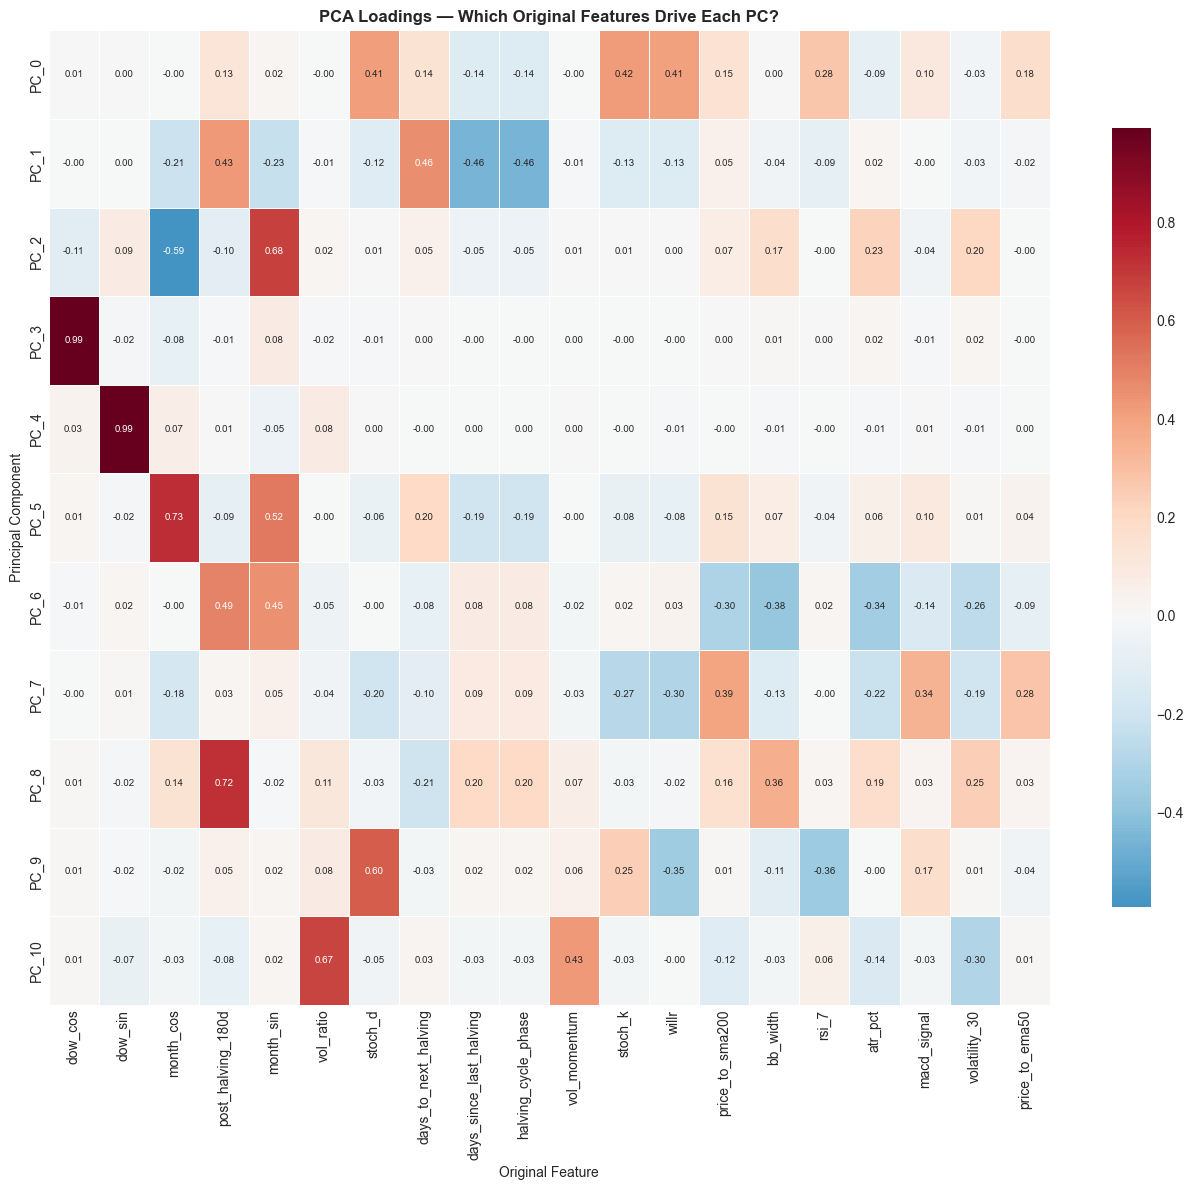

In [41]:
# ── PCA Component Interpretation ─────────────────────────────────────────────
# PCA components itu abstrak — tapi kita bisa interpretasi:
# PC yang punya loading tinggi pada fitur tertentu = proxy fitur tersebut

print('\n🔬 PCA Component Interpretation:')
print('(Menunjukkan kontribusi fitur asli ke setiap Principal Component)')
print()

loadings = pd.DataFrame(
    pca.components_.T,
    index=TECH_FEATURES,
    columns=[f'PC_{i}' for i in range(N_PCA)]
)

# Top fitur per PC
for i in range(min(5, N_PCA)):
    pc_col = f'PC_{i}'
    top3 = loadings[pc_col].abs().nlargest(3)
    explained = pca.explained_variance_ratio_[i] * 100
    print(f'  PC_{i} ({explained:.1f}% variance): {dict(zip(top3.index, top3.round(3).values))}')

# Heatmap loadings
fig, ax = plt.subplots(figsize=(min(16, N_PCA * 1.2), 12))
top_features = loadings.abs().max(axis=1).nlargest(20).index
sns.heatmap(loadings.loc[top_features].T, 
            cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax,
            annot_kws={'size': 7})
ax.set_title('PCA Loadings — Which Original Features Drive Each PC?', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Original Feature')
ax.set_ylabel('Principal Component')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()


## 💾 9. Export — Simpan Semua Artefak

Semua artefak disimpan di `./models_output/` dan siap digunakan oleh backend pipeline.

### Yang Disimpan:
- **Preprocessing artefak:** `feature_scaler.pkl`, `pca_transformer.pkl`, `target_scaler_*.pkl`
- **XGBoost models:** `xgb_model_*.pkl`
- **LSTM models:** `lstm_*.keras`
- **Metadata:** `model_metadata.json` (metrics, feature names, config)


In [42]:
# ── Export Preprocessing Artefak ─────────────────────────────────────────────
print('💾 Menyimpan semua artefak...')
print()

# Scaler & PCA
joblib.dump(tech_scaler, OUTPUT_DIR / 'feature_scaler.pkl')
joblib.dump(pca,         OUTPUT_DIR / 'pca_transformer.pkl')
print('✅ feature_scaler.pkl')
print('✅ pca_transformer.pkl')

# Target scalers per horizon
for target, scaler in target_scalers.items():
    fname = f'target_scaler_{target}.pkl'
    joblib.dump(scaler, OUTPUT_DIR / fname)
    print(f'✅ {fname}')

# ── Export XGBoost Models ─────────────────────────────────────────────────────
for target, model in xgb_models.items():
    fname = f'xgb_model_{target}.pkl'
    joblib.dump(model, OUTPUT_DIR / fname)
    print(f'✅ {fname}')

# ── Export LSTM Models ────────────────────────────────────────────────────────
for target, model in lstm_models.items():
    fname = f'lstm_{target}.keras'
    model.save(OUTPUT_DIR / fname)
    print(f'✅ {fname}')

# ── Export TFT Model ──────────────────────────────────────────────────────────
if TFT_AVAILABLE and tft_models:
    import torch
    for target, model in tft_models.items():
        fname = f'tft_{target}.pt'
        torch.save(model.state_dict(), OUTPUT_DIR / fname)
        print(f'✅ {fname}')

# ── Export Metadata ───────────────────────────────────────────────────────────
metadata = {
    'created_at'         : datetime.now().isoformat(),
    'config': {
        'start_date'     : START_DATE,
        'symbol'         : SYMBOL,
        'sequence_length': SEQUENCE_LEN,
        'n_pca_components': N_PCA,
        'train_ratio'    : TRAIN_RATIO,
        'targets'        : TARGET_COLS,
    },
    'features': {
        'tech_features'      : TECH_FEATURES,
        'sentiment_features' : SENTIMENT_FEATURES,
        'n_tech_features'    : len(TECH_FEATURES),
        'n_sentiment_features': len(SENTIMENT_FEATURES),
        'n_pca_components'   : N_PCA,
        'total_model_features': N_PCA + len(SENTIMENT_FEATURES),
    },
    'halving_dates': [str(d.date()) for d in HALVING_DATES],
    'results': [
        {k: float(v) if isinstance(v, (np.floating, float)) else v
         for k, v in {
             'model': r['model'], 'target': r['target'],
             'rmse': r['rmse'], 'mae': r['mae'],
             'da': r['da'], 'da_weighted': r['da_weighted']
         }.items()}
        for r in all_results
    ]
}

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

with open(OUTPUT_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, cls=NumpyEncoder)
    
print('✅ model_metadata.json')

print()
print('=' * 60)
print('SEMUA ARTEFAK BERHASIL DISIMPAN')
print(f'📁 Location: {OUTPUT_DIR.resolve()}')
print('=' * 60)
print()

# Final summary
print('\n📊 FINAL MODEL PERFORMANCE SUMMARY:')
print()
best_by_da = {}
for r in all_results:
    key = r['target']
    if key not in best_by_da or r['da'] > best_by_da[key]['da']:
        best_by_da[key] = r

for target, r in best_by_da.items():
    print(f'  🏆 Best for {target}: {r["model"]}')
    print(f'     DA={r["da"]:.2f}% | RMSE={r["rmse"]:.6f}')


💾 Menyimpan semua artefak...

✅ feature_scaler.pkl
✅ pca_transformer.pkl
✅ target_scaler_target_y1.pkl
✅ target_scaler_target_y7.pkl
✅ target_scaler_target_y30.pkl
✅ xgb_model_target_y1.pkl
✅ xgb_model_target_y7.pkl
✅ xgb_model_target_y30.pkl
✅ lstm_target_y1.keras
✅ lstm_target_y7.keras
✅ lstm_target_y30.keras
✅ tft_target_y1.pt
✅ model_metadata.json

SEMUA ARTEFAK BERHASIL DISIMPAN
📁 Location: D:\Code\PROJECT-ML_Pribadi\Bitcoin-MLOps-dashboard\Research-Modelling\models_output


📊 FINAL MODEL PERFORMANCE SUMMARY:

  🏆 Best for target_y1: TFT
     DA=100.00% | RMSE=0.016541
  🏆 Best for target_y7: XGBoost
     DA=58.85% | RMSE=0.074989
  🏆 Best for target_y30: XGBoost
     DA=61.48% | RMSE=0.147026


In [43]:
# ── DIAGNOSIS TFT LEAKAGE ─────────────────────────────────────────────────────

# 1. Cek ukuran actual validation set
val_dl_check = tft_dataset.to_dataloader(train=False, batch_size=256, num_workers=0)
output_check = tft_model.predict(val_dl_check, mode='prediction', return_x=True)

preds_check   = output_check[0].numpy().flatten()
actuals_check = output_check[1]['decoder_target'].numpy().flatten()

print(f'Validation samples : {len(preds_check)}')
print(f'preds  range       : [{preds_check.min():.4f}, {preds_check.max():.4f}]')
print(f'actuals range      : [{actuals_check.min():.4f}, {actuals_check.max():.4f}]')
print()

# 2. Cek apakah preds == actuals (perfect leakage)
perfect_match = np.mean(np.isclose(preds_check, actuals_check, atol=1e-4)) * 100
print(f'Perfect value match: {perfect_match:.1f}%')
print()

# 3. Cek sign match breakdown
sign_match = np.sign(preds_check) == np.sign(actuals_check)
print(f'Sign match         : {sign_match.mean()*100:.1f}%')
print(f'Preds always +     : {(preds_check > 0).mean()*100:.1f}%')
print(f'Preds always -     : {(preds_check < 0).mean()*100:.1f}%')
print(f'Actuals % positive : {(actuals_check > 0).mean()*100:.1f}%')
print()

# 4. Cek training_cutoff vs total data
print(f'Total tft_df rows  : {tft_df_debug["time_idx"].max() if "tft_df_debug" in dir() else "run train_tft again to capture"}')
print(f'training_cutoff    : lihat output train_tft di atas')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Validation samples : 1791
preds  range       : [0.0000, 0.0082]
actuals range      : [-0.5026, 0.1784]

Perfect value match: 0.1%

Sign match         : 50.9%
Preds always +     : 100.0%
Preds always -     : 0.0%
Actuals % positive : 50.9%

Total tft_df rows  : run train_tft again to capture
training_cutoff    : lihat output train_tft di atas
